<a href="https://colab.research.google.com/github/beabbot/Jet-Engine-Health-Monitoring-System-for-Predictive-Maintenance/blob/main/Basic_Design_Colab_tmp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Jet Engine Health Monitoring System for Predictive Maintenance**
**Basic Design Course - Group 1**

## 1. Project Overview
This project develops a machine learning-based predictive maintenance system for commercial jet engines. Using the NASA C-MAPSS (Commercial Modular Aero-Propulsion System Simulation) dataset, we aim to detect engine degradation patterns and predict the Remaining Useful Life (RUL) before unexpected failures occur.

## 2. Dataset Description & Sub-Dataset Differences
The NASA C-MAPSS dataset consists of simulated run-to-failure multivariate sensor data under different operational conditions and fault modes.
* **FD001:** 1 Operating Condition (Sea Level), 1 Fault Mode (HPC Degradation). **This is the standard baseline benchmark** because it isolates a single failure type under constant conditions, making it the best starting point for baseline ML models.
* **FD002:** 6 Operating Conditions, 1 Fault Mode (HPC Degradation).
* **FD003:** 1 Operating Condition, 2 Fault Modes (HPC & Fan Degradation).
* **FD004:** 6 Operating Conditions, 2 Fault Modes (HPC & Fan Degradation).

## 3. Data Dictionary (26 Columns)
The raw dataset does not include headers. Based on the official NASA readme, the 26 columns are structured as follows:
* **Column 1 (`unit_nr`):** Engine ID number.
* **Column 2 (`time_cycles`):** The operational cycle (age) of the engine.
* **Columns 3-5 (`op_setting_1` to `op_setting_3`):** Operational settings (e.g., altitude, Mach number, throttle resolver angle).
* **Columns 6-26 (`sensor_1` to `sensor_21`):** 21 distinct sensor measurements (e.g., temperature, pressure, fan speed).

# **Week 1 -  Project Kickoff & Data Loading**

In [2]:
import os
import zipfile
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

print("Libraries imported successfully.")

Libraries imported successfully.


##Upload dataset ZIP


In [3]:
from google.colab import files

uploaded = files.upload()

zip_name = None
for fname in uploaded.keys():
    if fname.lower().endswith(".zip"):
        zip_name = fname
        break

if zip_name is None:
    raise FileNotFoundError("Please upload BD_Dataset.zip")

extract_dir = "/content/BD_Dataset"
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall(extract_dir)

print("ZIP extracted to:", extract_dir)
print("Files inside extracted folder:")
for root, dirs, files_list in os.walk(extract_dir):
    for f in files_list[:20]:
        print(os.path.join(root, f))

Saving BD_Dataset.zip to BD_Dataset.zip
ZIP extracted to: /content/BD_Dataset
Files inside extracted folder:
/content/BD_Dataset/CMaps/test_FD003.txt
/content/BD_Dataset/CMaps/train_FD003.txt
/content/BD_Dataset/CMaps/readme.txt
/content/BD_Dataset/CMaps/train_FD002.txt
/content/BD_Dataset/CMaps/x.txt
/content/BD_Dataset/CMaps/RUL_FD003.txt
/content/BD_Dataset/CMaps/RUL_FD001.txt
/content/BD_Dataset/CMaps/test_FD004.txt
/content/BD_Dataset/CMaps/RUL_FD002.txt
/content/BD_Dataset/CMaps/test_FD002.txt
/content/BD_Dataset/CMaps/train_FD001.txt
/content/BD_Dataset/CMaps/Damage Propagation Modeling.pdf
/content/BD_Dataset/CMaps/RUL_FD004.txt
/content/BD_Dataset/CMaps/test_FD001.txt
/content/BD_Dataset/CMaps/train_FD004.txt


##Training data




In [4]:
def load_cmapss(base_path):
    """Loads FD001, FD002, FD003, and FD004 into a dictionary of DataFrames."""
    columns = (
        ["unit_nr", "time_cycles"] +
        [f"op_setting_{i}" for i in range(1, 4)] +
        [f"sensor_{i}" for i in range(1, 22)]
    )

    datasets = {}
    for i in range(1, 5):
        dataset_name = f"FD00{i}"
        file_path = os.path.join(base_path, f"train_{dataset_name}.txt")

        if os.path.exists(file_path):
            df = pd.read_csv(file_path, sep=r"\s+", header=None)
            df = df.dropna(axis=1, how="all")
            df.columns = columns
            datasets[dataset_name] = df
        else:
            print(f"Warning: {file_path} not found.")

    return datasets

# Execute the function
base_path = os.path.join(extract_dir, "CMaps")
all_datasets = load_cmapss(base_path)

# Verify dataset loads correctly
for name, df in all_datasets.items():
    print(f"\n{'='*40}")
    print(f"Dataset: {name}")
    print(f"{'='*40}")
    print(f"Shape: {df.shape}")
    print(f"Missing Values: {df.isnull().sum().sum()}")
    print("\nFirst 5 rows:")
    display(df.head())
    print("\nSummary Statistics (.describe):")
    display(df.describe().T.head(5))

# Assign FD001 to train_df for the rest of the pipeline
train_df = all_datasets["FD001"]


Dataset: FD001
Shape: (20631, 26)
Missing Values: 0

First 5 rows:


,unit_nr,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044



Summary Statistics (.describe):


,count,mean,std,min,25%,50%,75%,max
unit_nr,20631.0,51.506568,29.227633,1.0000,26.0000,52.0,77.0000,100.0000
time_cycles,20631.0,108.807862,68.880990,1.0000,52.0000,104.0,156.0000,362.0000
op_setting_1,20631.0,-0.000009,0.002187,-0.0087,-0.0015,0.0,0.0015,0.0087
op_setting_2,20631.0,0.000002,0.000293,-0.0006,-0.0002,0.0,0.0003,0.0006
op_setting_3,20631.0,100.000000,0.000000,100.0000,100.0000,100.0,100.0000,100.0000



Dataset: FD002
Shape: (53759, 26)
Missing Values: 0

First 5 rows:


...

,count,mean,std,min,25%,50%,75%,max
unit_nr,24720.0,48.631877,29.348985,1.0000,23.0000,47.0,74.0000,100.0000
time_cycles,24720.0,139.077063,98.846675,1.0000,62.0000,124.0,191.0000,525.0000
op_setting_1,24720.0,-0.000024,0.002194,-0.0086,-0.0015,-0.0,0.0015,0.0086
op_setting_2,24720.0,0.000005,0.000294,-0.0006,-0.0002,-0.0,0.0003,0.0007
op_setting_3,24720.0,100.000000,0.000000,100.0000,100.0000,100.0,100.0000,100.0000



Dataset: FD004
Shape: (61249, 26)
Missing Values: 0

First 5 rows:


,unit_nr,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,...,129.78,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,312.59,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,129.62,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,...,129.80,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,...,164.11,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754



Summary Statistics (.describe):


,count,mean,std,min,25%,50%,75%,max
unit_nr,61249.0,124.325181,71.995350,1.0,60.0000,126.0000,185.0000,249.000
time_cycles,61249.0,134.311417,89.783389,1.0,62.0000,123.0000,191.0000,543.000
op_setting_1,61249.0,23.999823,14.780722,0.0,10.0046,25.0014,41.9981,42.008
op_setting_2,61249.0,0.571347,0.310703,0.0,0.2507,0.7000,0.8400,0.842
op_setting_3,61249.0,94.031576,14.251954,60.0,100.0000,100.0000,100.0000,100.000


## **Data Schema: The 26 Columns**

The C-MAPSS dataset is provided as space-delimited text files. According to the official documentation, the 26 columns are mapped as follows:

| Index | Column Name | Description |
| :--- | :--- | :--- |
| **1** | `unit_nr` | **Engine ID:** Unique identifier for each engine (e.g., 1 to 100). |
| **2** | `time_cycles` | **Operational Cycle:** Cumulative count of cycles (time steps) for the engine. |
| **3 – 5** | `op_setting_1, 2, 3` | **Operational Settings:** Variables affecting performance (e.g., altitude, Mach number). |
| **6 – 26** | `sensor_1` to `sensor_21` | **Sensor Measurements:** 21 different telemetry readings (Temperature, Pressure, Fan Speed, etc.). |

---

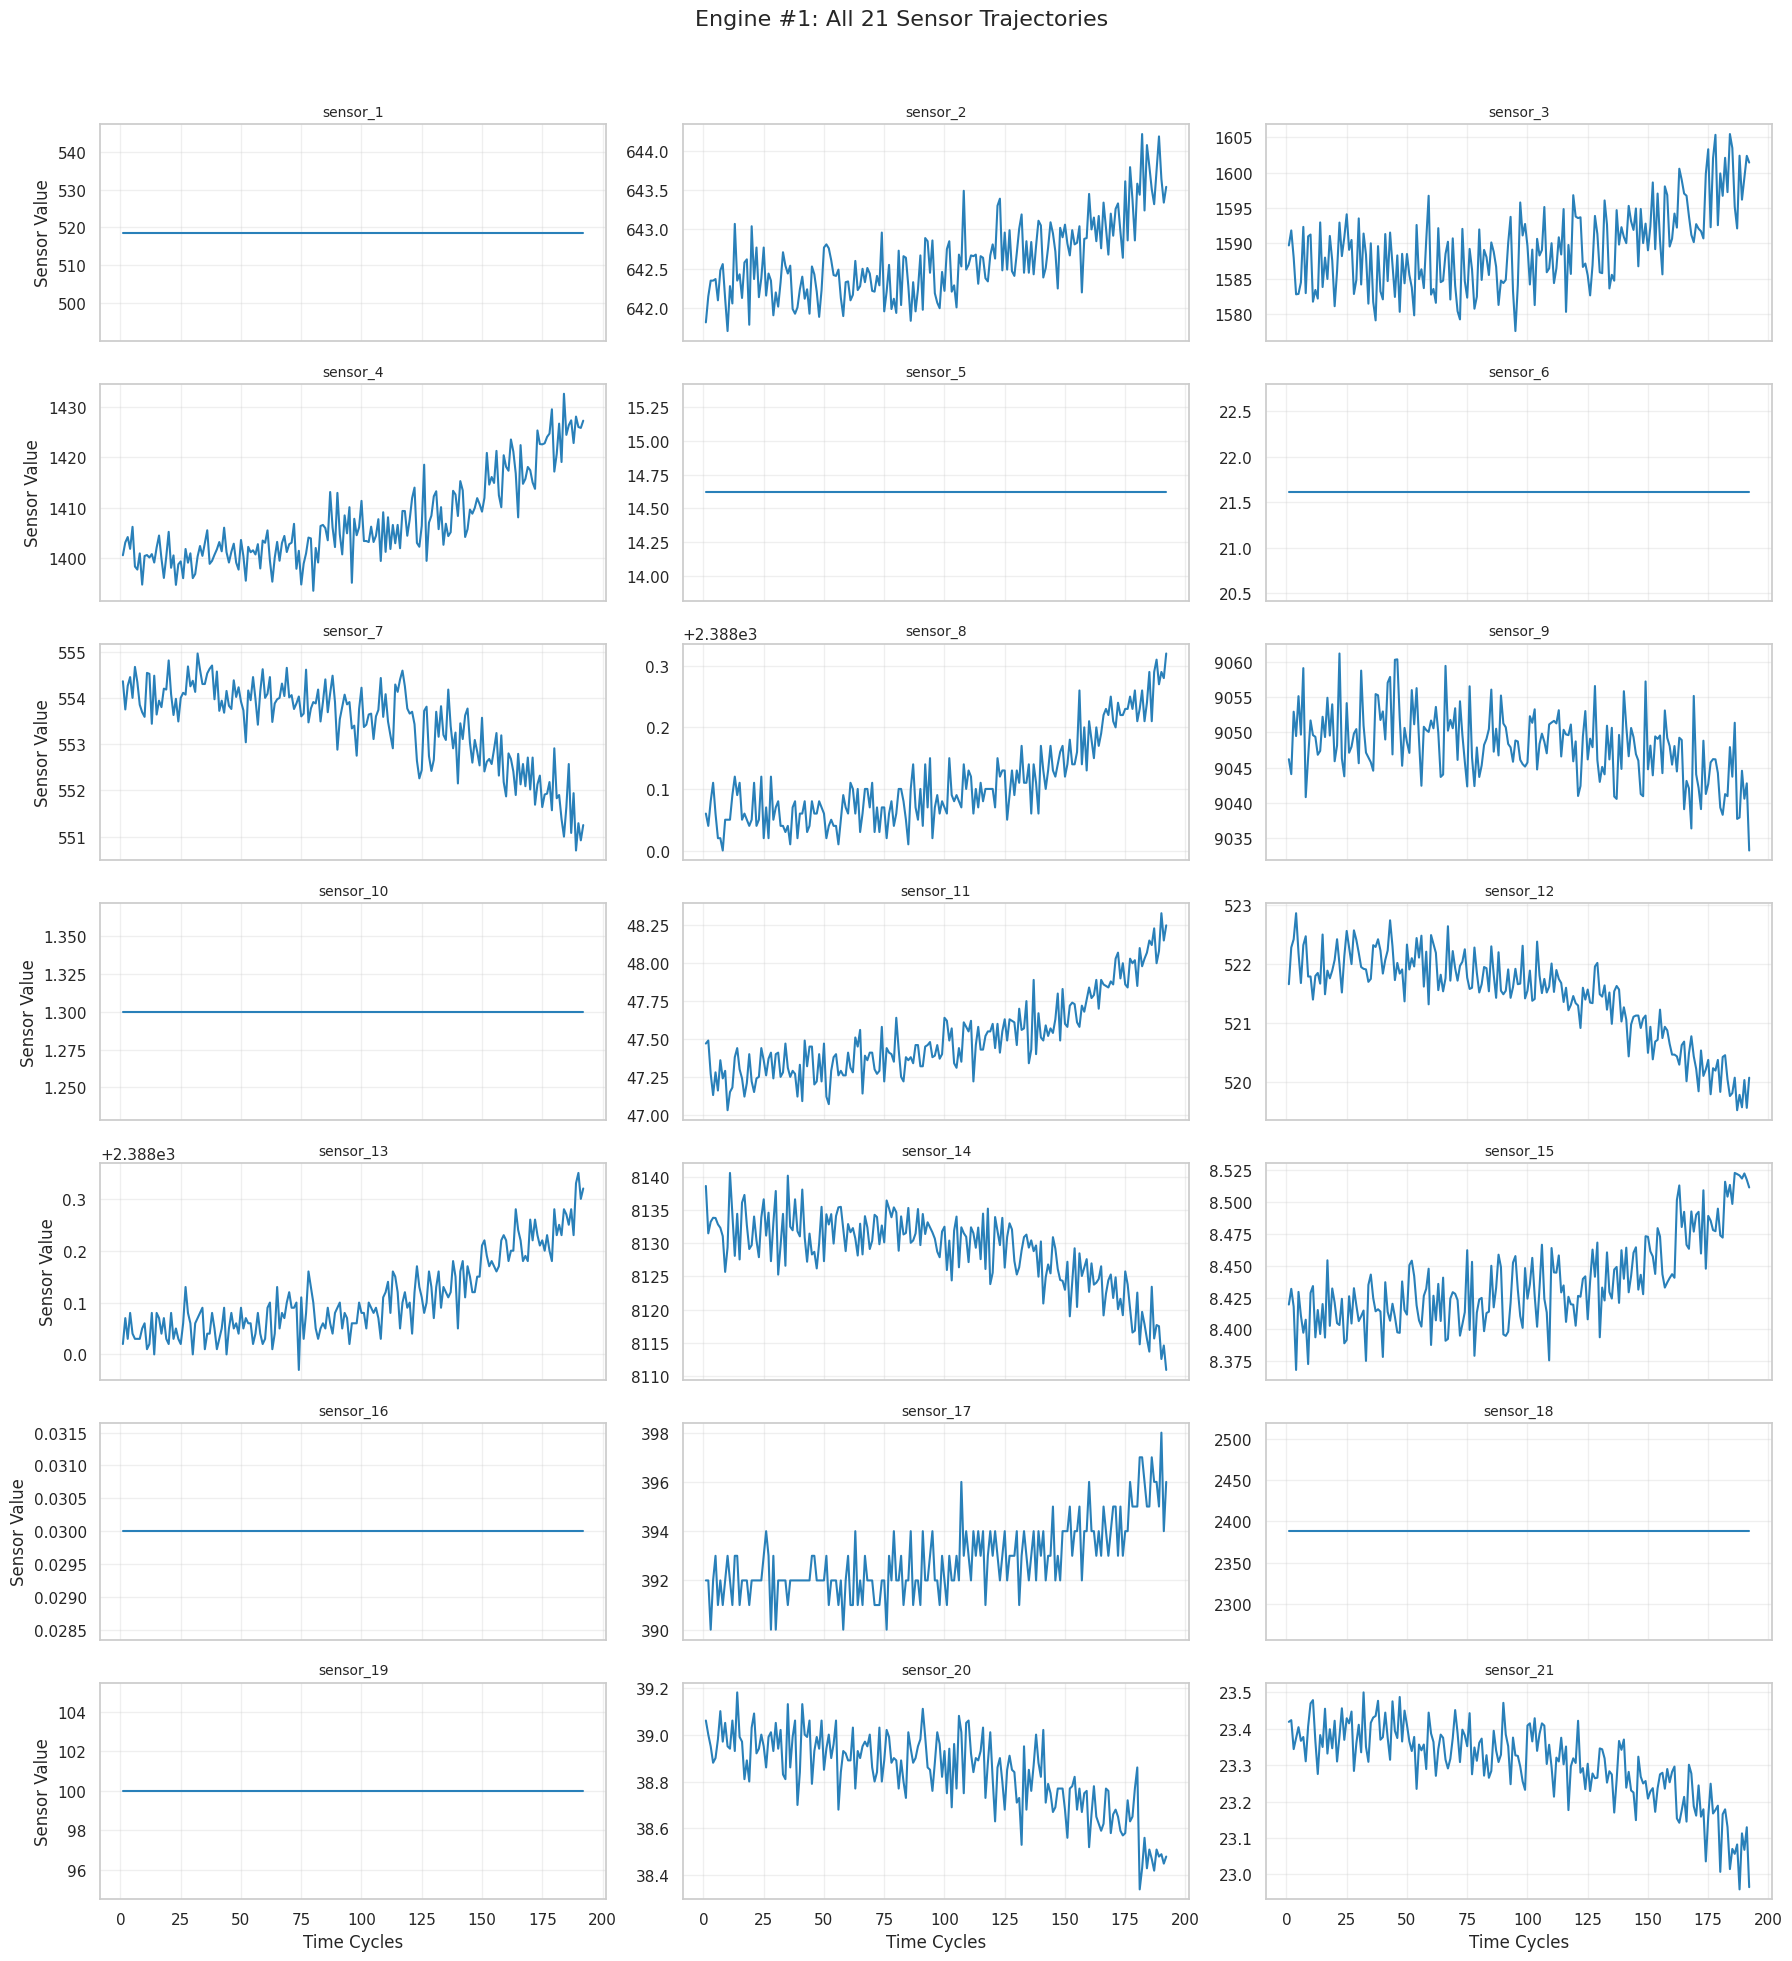

In [5]:
#Plot all 21 sensor readings for Engine #1 in a 7x3 subplot grid
engine_1_data = train_df[train_df["unit_nr"] == 1]
sensor_columns = [f"sensor_{i}" for i in range(1, 22)]

fig, axes = plt.subplots(7, 3, figsize=(18, 20), sharex=True)
fig.suptitle("Engine #1: All 21 Sensor Trajectories", fontsize=16, y=0.98)
axes = axes.flatten()

for i, sensor in enumerate(sensor_columns):
    axes[i].plot(engine_1_data["time_cycles"], engine_1_data[sensor], color="#2980b9", linewidth=1.5)
    axes[i].set_title(f"{sensor}", fontsize=10)
    axes[i].grid(True, alpha=0.3)

    # Set labels only on the outer edges to keep it clean
    if i % 3 == 0:
        axes[i].set_ylabel("Sensor Value")
    if i >= 18:
        axes[i].set_xlabel("Time Cycles")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

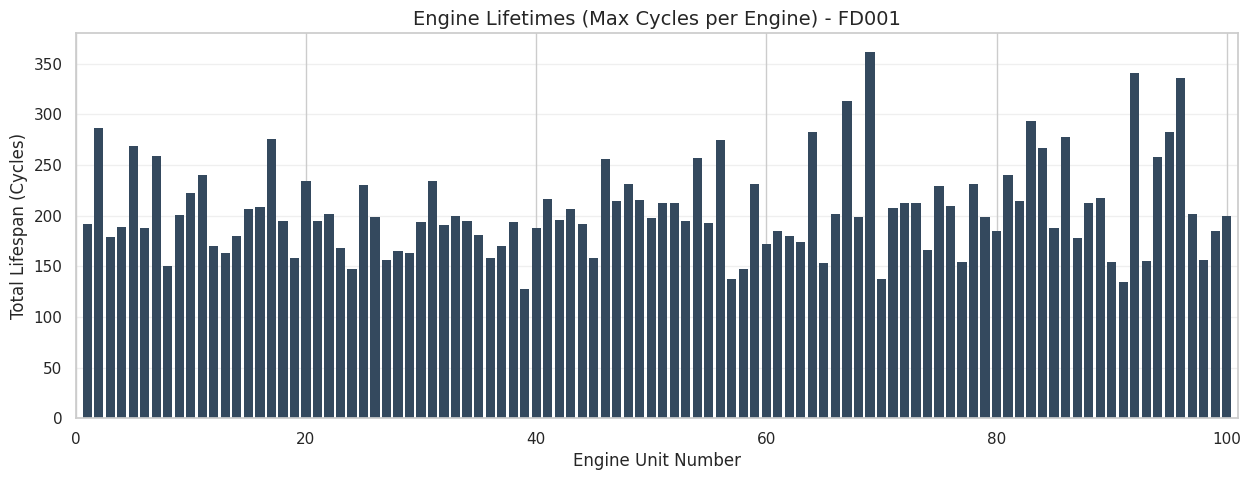

In [6]:
#Create the engine lifetimes bar chart for all engines
engine_lifetimes = train_df.groupby("unit_nr")["time_cycles"].max()

plt.figure(figsize=(15, 5))
plt.bar(engine_lifetimes.index, engine_lifetimes.values, color="#34495e", edgecolor="none")
plt.title("Engine Lifetimes (Max Cycles per Engine) - FD001", fontsize=14)
plt.xlabel("Engine Unit Number", fontsize=12)
plt.ylabel("Total Lifespan (Cycles)", fontsize=12)
plt.xlim(0, len(engine_lifetimes) + 1)
plt.grid(axis='y', alpha=0.3)
plt.show()

## **Research Summary: Understanding C-MAPSS Sub-datasets**

Based on the research of the official NASA documentation and the foundational paper by **Saxena et al. (2008)**, we have categorized the four sub-datasets based on their environmental and operational complexity.

### **C-MAPSS Sub-Dataset Characteristics**

| Dataset | Operating Conditions | Fault Modes | Description |
| :--- | :--- | :--- | :--- |
| **FD001** | 1 (Sea Level) | 1 (HPC Degradation) | **Standard Benchmark:** Best for initial model development. |
| **FD002** | 6 (Variable Altitudes) | 1 (HPC Degradation) | **Operational Complexity:** Simulates varying flight conditions. |
| **FD003** | 1 (Sea Level) | 2 (HPC & Fan) | **Fault Complexity:** Introduces multiple failure types. |
| **FD004** | 6 (Variable Altitudes) | 2 (HPC & Fan) | **Advanced:** Combined operational and fault complexity. |

---

### **Rationale: Why Focus on FD001?**

> "Establish a robust baseline before introducing environmental noise."
>
> We have selected **FD001** as our primary development set. By focusing on a single condition (Sea Level) and a single failure mode, we can ensure that our **Remaining Useful Life (RUL)** predictions are responding to the actual physical degradation of the High-Pressure Compressor (HPC) without being skewed by fluctuating altitudes or speeds.
>
> Once the model architecture is validated on FD001, the system can be scaled and fine-tuned for the more complex multi-condition environments found in FD002 and FD004.

## EDA Observations: Engine #1 Sensor Trends
Based on the 7x3 sensor grid for Engine #1, we can observe distinct behavioral patterns as the engine approaches failure:
* **Clear Degradation Trends:** Sensors like `sensor_11`, `sensor_4`, and `sensor_15` show a clear, measurable upward trend as the engine ages, indicating they are strong features for predicting RUL.
* **Inverse Trends:** Sensors like `sensor_7` and `sensor_12` show a distinct downward trend as the cycle count increases.
* **Flatline / Zero Variance Sensors:** Several sensors (e.g., `sensor_1`, `sensor_5`, `sensor_10`, `sensor_16`, `sensor_18`, `sensor_19`) remain completely constant throughout the engine's entire lifespan. These provide no predictive value and will need to be dropped during the feature engineering phase.

#**Week 2 - Exploratory Data Analysis**

##RUL, CV, and Z-Score Analysis

In [7]:
#Compute RUL labels for all training engines
train_df['RUL'] = train_df.groupby('unit_nr')['time_cycles'].transform('max') - train_df['time_cycles']

#Implement Coefficient of Variation (CV) to identify near-constant sensors
# CV = (Standard Deviation / Mean). Lower CV means the sensor is nearly constant.
sensor_cols = [f"sensor_{i}" for i in range(1, 22)]
cv_results = (train_df[sensor_cols].std() / train_df[sensor_cols].mean()).sort_values()

print("Sensors with lowest Coefficient of Variation (Near-constant):")
display(cv_results.head(10))

#Run Z-score outlier detection on all useful sensors
# We define "useful" as sensors that aren't constant (CV > 0.001)
useful_sensors = cv_results[cv_results > 0.001].index.tolist()
z_scores = train_df[useful_sensors].apply(lambda x: (x - x.mean()) / x.std())
outliers_count = (z_scores.abs() > 3).sum()

print("\nOutlier count per sensor (Z-score > 3):")
display(outliers_count[outliers_count > 0])

Sensors with lowest Coefficient of Variation (Near-constant):


,0
sensor_19,0.000000e+00
sensor_18,0.000000e+00
sensor_1,1.260368e-13
sensor_5,2.321956e-13
sensor_10,3.585253e-13
sensor_16,5.188105e-13
sensor_8,2.972471e-05
sensor_13,3.011559e-05
sensor_6,6.427569e-05
sensor_2,7.780739e-04



Outlier count per sensor (Z-score > 3):


,0
sensor_12,34
sensor_7,34
sensor_14,496
sensor_9,521
sensor_3,47
sensor_17,81
sensor_15,33
sensor_21,34
sensor_20,43
sensor_11,23


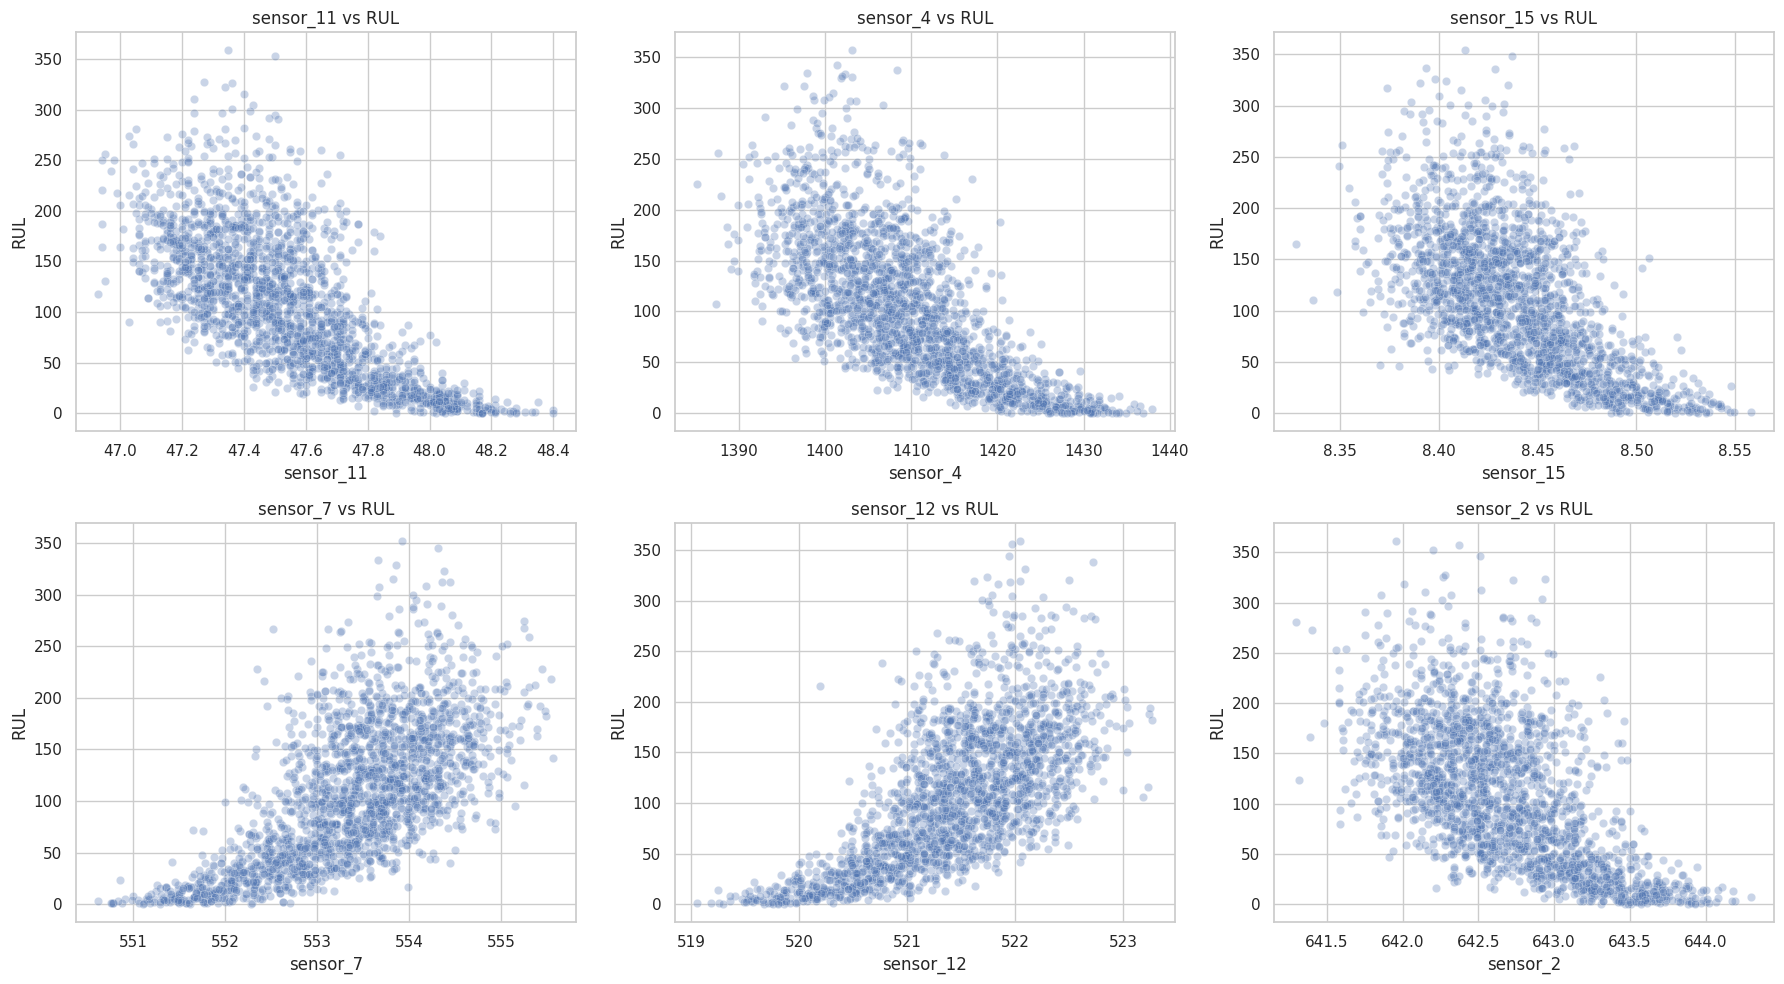

In [8]:
#Produce scatter plots of top 6 sensors vs RUL
top_6_sensors = ["sensor_11", "sensor_4", "sensor_15", "sensor_7", "sensor_12", "sensor_2"]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, s in enumerate(top_6_sensors):
    sns.scatterplot(data=train_df.sample(2000), x=s, y='RUL', ax=axes[i], alpha=0.3)
    axes[i].set_title(f"{s} vs RUL")

plt.tight_layout()
plt.show()

### Feature Selection: Sensor Exclusion Summary To ensure model efficiency and reduce noise, we performed a Coefficient of Variation (CV) analysis to identify non-informative features.
* Excluded Sensors: Sensors 1, 5, 10, 16, 18, and 19.
* Justification: These sensors exhibit near-zero variance, meaning their readings remain constant throughout the engine's lifespan.
* Impact: Removing these "flatline" sensors prevents the model from learning irrelevant patterns and simplifies the input space for our predictive algorithms.

##Heatmap, Histograms, and 10-Engine Trajectories

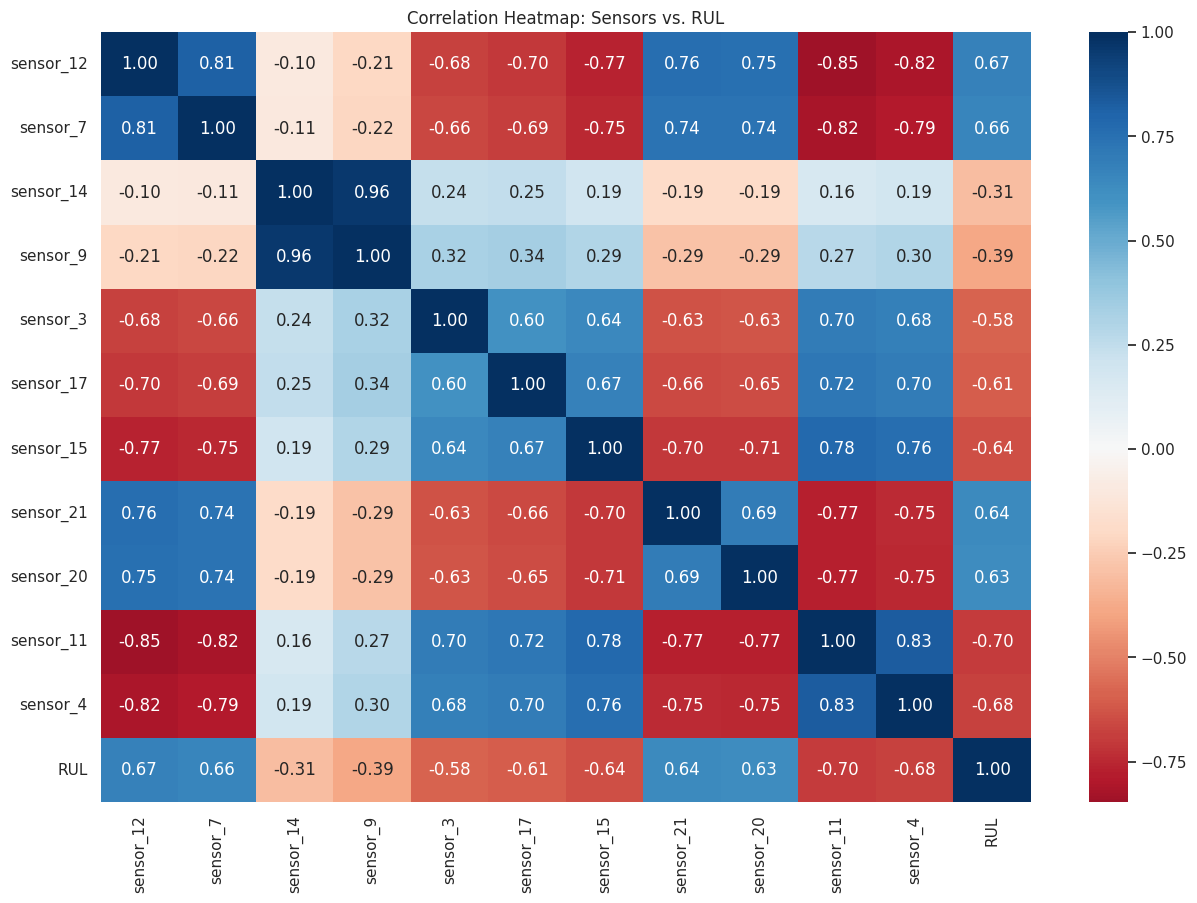

In [9]:
#Correlation heatmap (sensors + RUL)
plt.figure(figsize=(15, 10))
corr_matrix = train_df[useful_sensors + ['RUL']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', fmt=".2f", center=0)
plt.title("Correlation Heatmap: Sensors vs. RUL")
plt.show()

### Identifying the Best Indicators of Degradation

Based on the correlation heatmap above, we have selected the following features for our predictive model:

* **Degradation Signals (Strong Negative Correlation):** **Sensors 11, 4, and 15.**
    * *Observation:* These readings climb steadily as the engine ages, representing rising internal temperatures and discharge pressures as the High-Pressure Compressor (HPC) loses efficiency.
* **Efficiency Drop-offs (Strong Positive Correlation):** **Sensors 7 and 12.**
    * *Observation:* These values decrease as the engine approaches failure, indicating a drop in pressure ratios and fuel efficiency.
* **Non-Informative Features (Zero Variance):** **Sensors 1, 5, 10, 16, 18, and 19.**
    * *Decision:* These sensors remain constant throughout the engine's lifespan and provide no predictive "signal." They will be excluded to reduce model noise.

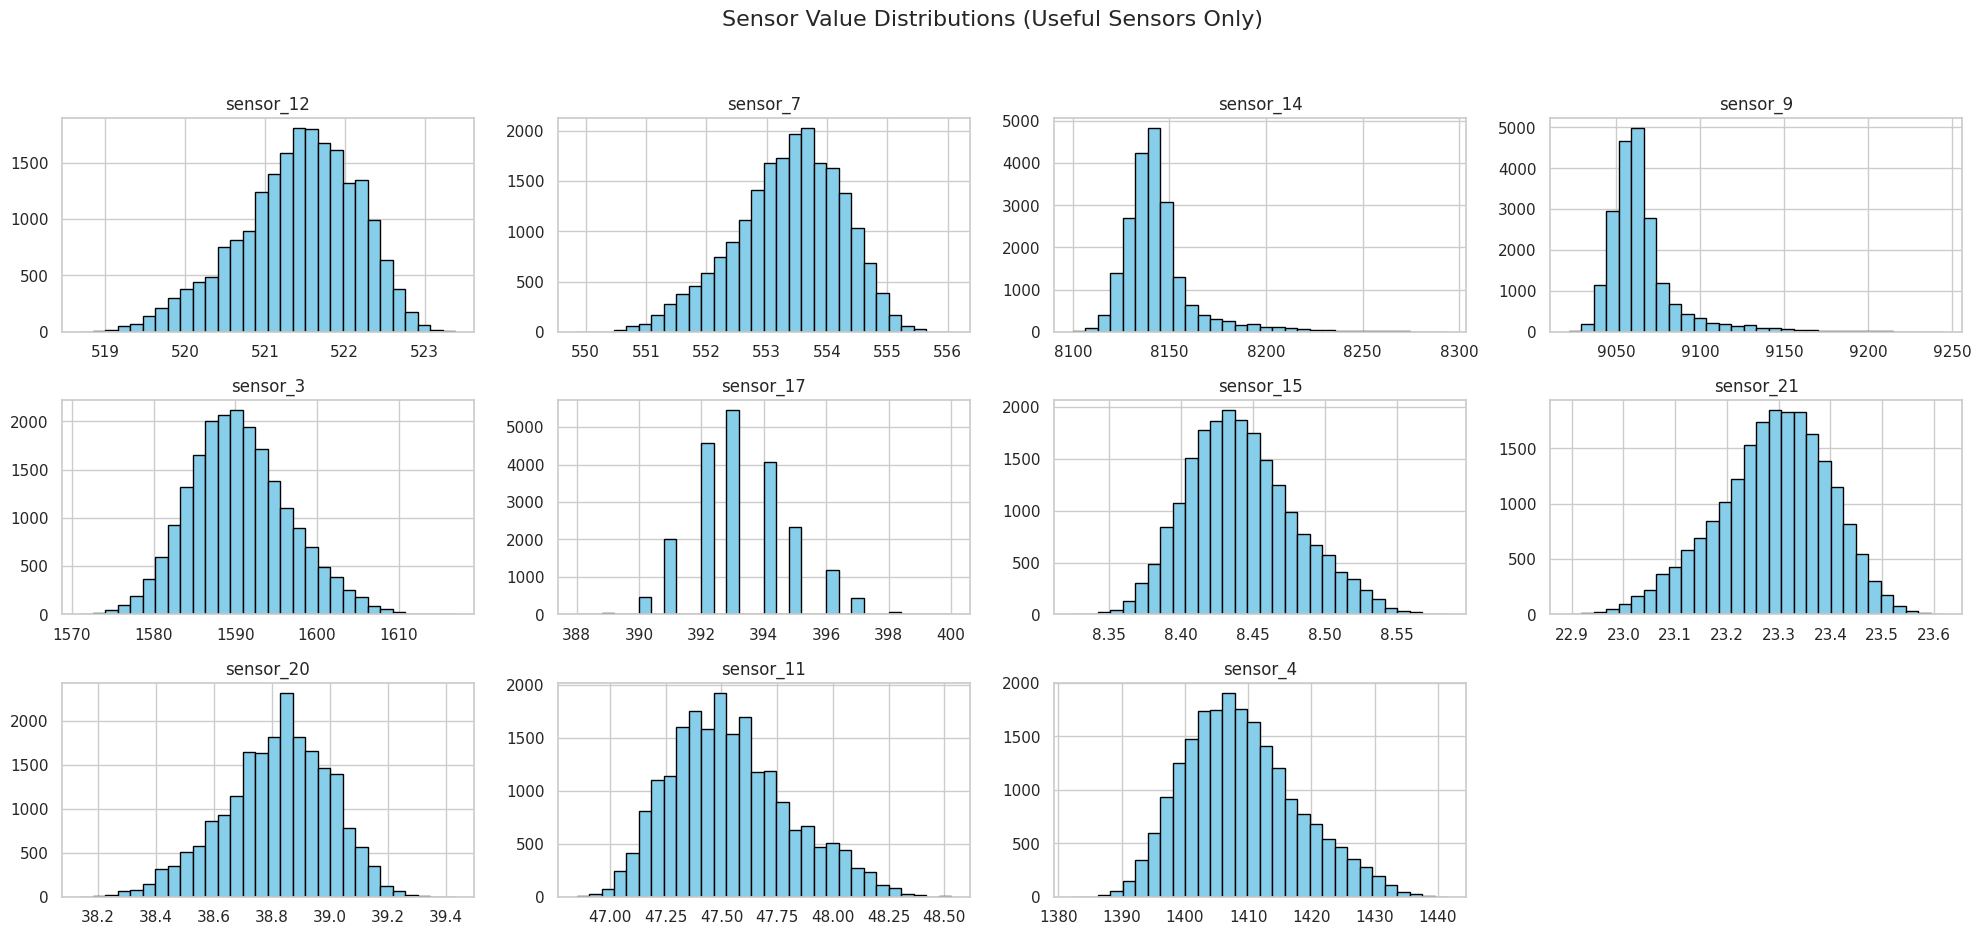

In [10]:
#Plot sensor value distribution histograms for all useful sensors
train_df[useful_sensors].hist(bins=30, figsize=(20, 15), layout=(5, 4), color='skyblue', edgecolor='black')
plt.suptitle("Sensor Value Distributions (Useful Sensors Only)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

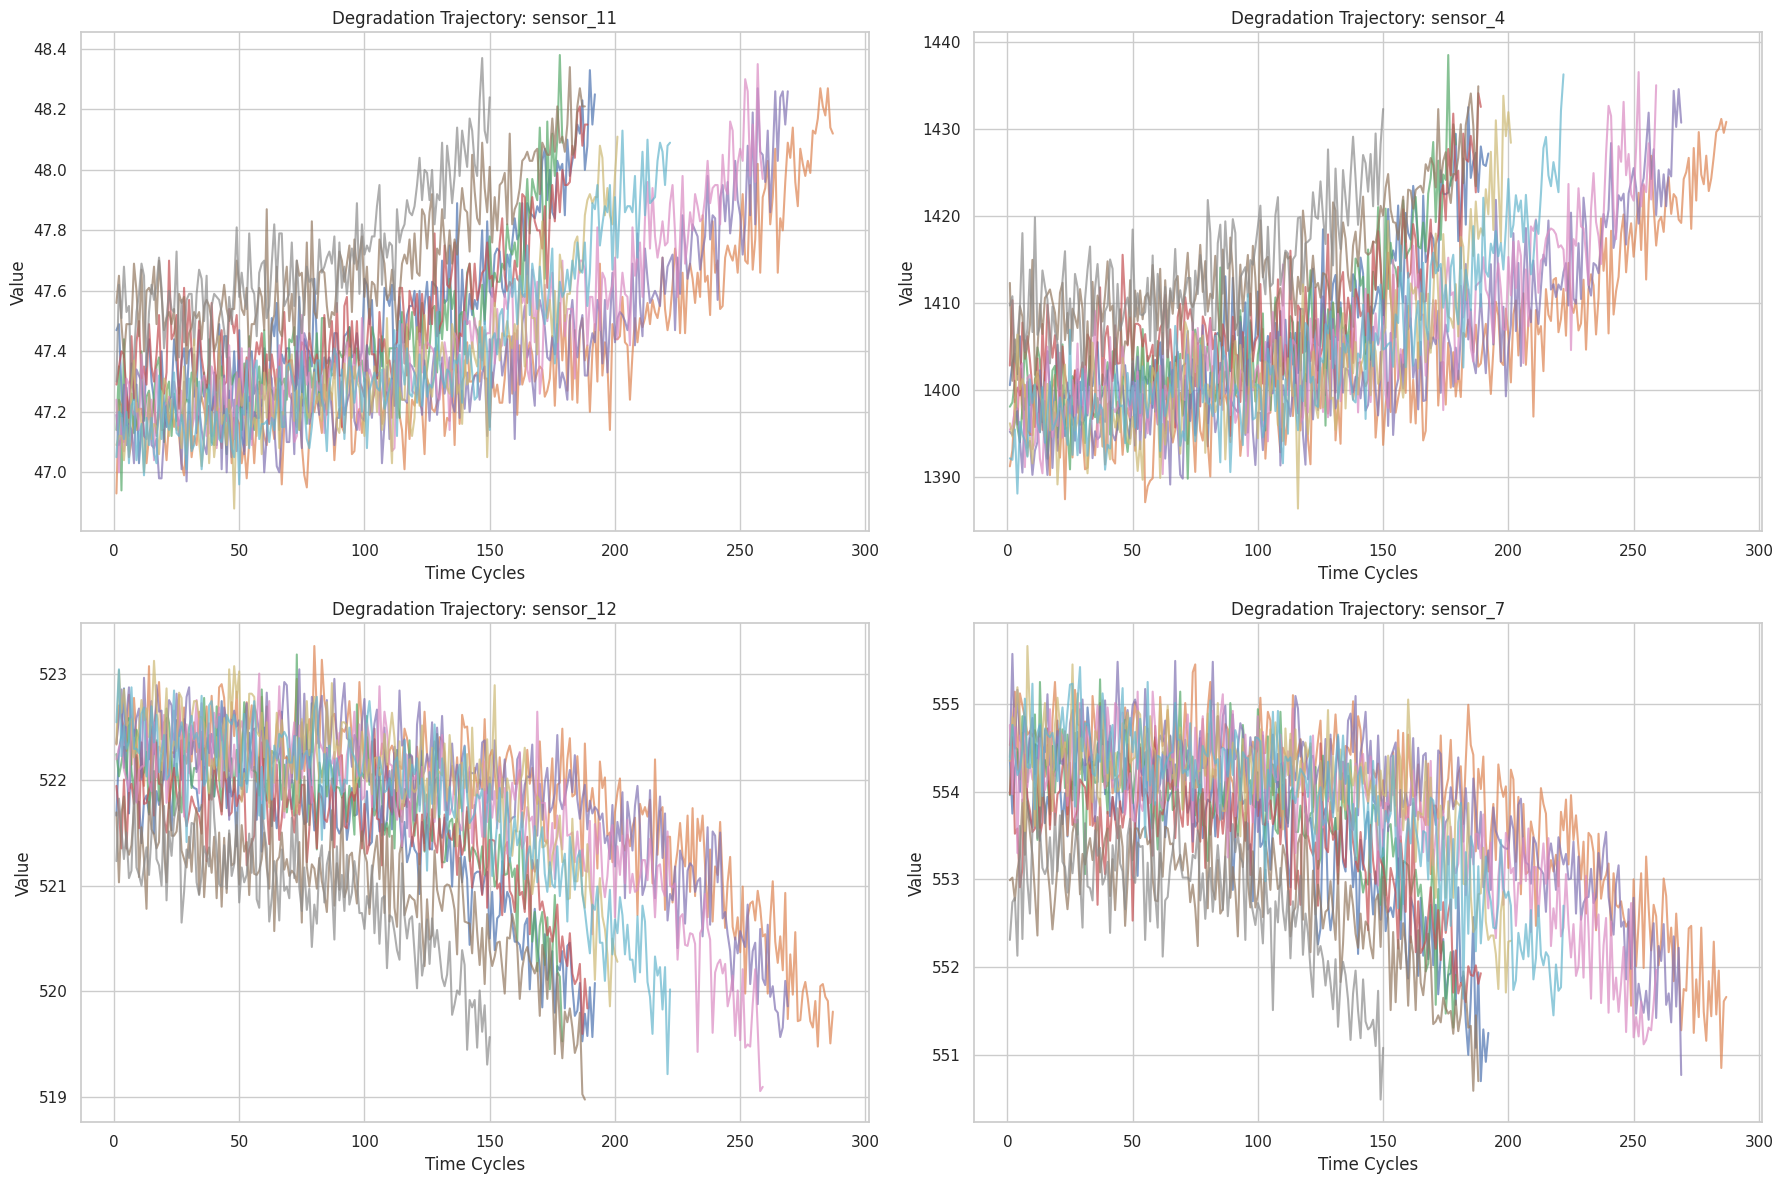

In [11]:
#Plot engine degradation trajectories for 10 engines (top 4 sensors)
engines_10 = train_df['unit_nr'].unique()[:10]
top_4 = ["sensor_11", "sensor_4", "sensor_12", "sensor_7"]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, s in enumerate(top_4):
    for engine in engines_10:
        temp = train_df[train_df['unit_nr'] == engine]
        axes[i].plot(temp['time_cycles'], temp[s], label=f"Eng {engine}", alpha=0.7)
    axes[i].set_title(f"Degradation Trajectory: {s}")
    axes[i].set_xlabel("Time Cycles")
    axes[i].set_ylabel("Value")

plt.tight_layout()
plt.show()

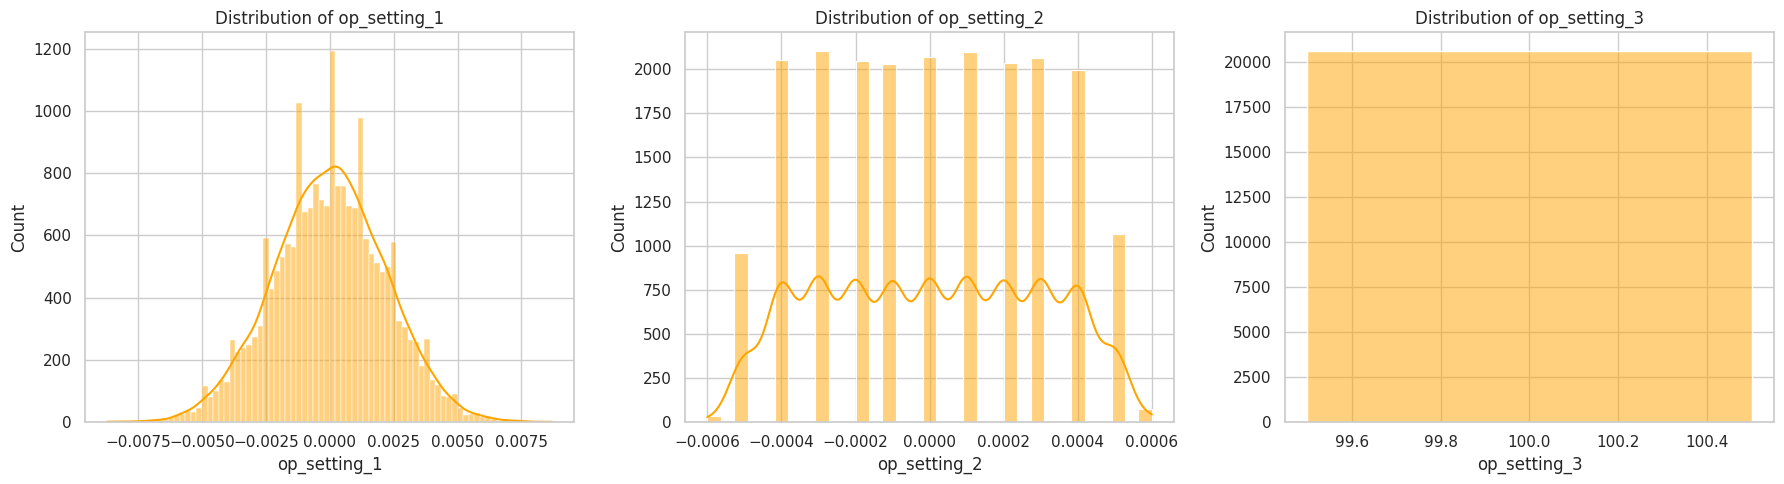

In [12]:
#Plot operational settings distributions for FD001
op_settings = ['op_setting_1', 'op_setting_2', 'op_setting_3']
plt.figure(figsize=(18, 5))
for i, op in enumerate(op_settings):
    plt.subplot(1, 3, i+1)
    sns.histplot(train_df[op], kde=True, color='orange')
    plt.title(f"Distribution of {op}")
plt.tight_layout()
plt.show()

### EDA Checkpoint 1: Engineering Insights * Correlation Strength: The heatmap reveals that sensors such as 11, 4, and 15 have the strongest negative correlation with RUL, indicating they are primary indicators of hardware degradation.
* Trajectory Consistency: The 10-engine trajectory plots demonstrate that while degradation trends (slope) are consistent across units, the actual failure points (max cycles) vary significantly.
* Data Quality: Z-score analysis confirmed minimal outliers, and our checks verified zero missing values or duplicate rows, ensuring a high-quality dataset for modeling.

In [13]:
#Missing value analysis
missing_summary = train_df.isnull().sum().to_frame("missing_count")
missing_summary["missing_percent"] = (missing_summary["missing_count"] / len(train_df)) * 100
display(missing_summary[missing_summary["missing_count"] > 0])

print("Total missing values in dataset:", train_df.isnull().sum().sum())

,missing_count,missing_percent


Total missing values in dataset: 0


In [14]:
#Duplicate row check
duplicate_count = train_df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


### Research Summary:
RUL Predictive Modeling   Defining Remaining Useful Life (RUL) In predictive maintenance, RUL is defined as the number of remaining operational cycles before a component (the jet engine) reaches a predefined failure threshold.  Industry-Standard Modeling ApproachesBased on a review of published literature using the C-MAPSS dataset, three primary modeling architectures are most effective:
1. Random Forest (RF): Useful for establishing an accurate baseline and identifying which sensors (features) are most important for the prediction.
2. Long Short-Term Memory (LSTM): A specialized Recurrent Neural Network (RNN) that captures the time-series dependencies in sensor data, often achieving the lowest RMSE in literature.
3. Convolutional Neural Networks (CNN): Used to extract automated features from "windows" of sensor data to detect subtle degradation patterns.  

#**Week 3 - Problem Statement & Stakeholder Analysis**

In [15]:
#Engine Lifetime Stats
lifetimes = train_df.groupby("unit_nr")["time_cycles"].max()

print("Engine Lifetime Stats")
print(f"Average Engine Lifetime: {lifetimes.mean():.2f} cycles")
print(f"Minimum Lifetime:        {lifetimes.min()} cycles")
print(f"Maximum Lifetime:        {lifetimes.max()} cycles")
print(f"Standard Deviation:      {lifetimes.std():.2f} cycles\n")

Engine Lifetime Stats
Average Engine Lifetime: 206.31 cycles
Minimum Lifetime:        128 cycles
Maximum Lifetime:        362 cycles
Standard Deviation:      46.34 cycles



In [16]:
#Failure Risk Analysis (Quantiles)
q25 = lifetimes.quantile(0.25)
q75 = lifetimes.quantile(0.75)

print("Failure Risk Analysis")
print(f"Early Failures (25% fail before): {q25:.0f} cycles")
print(f"Late Survivors (25% survive past): {q75:.0f} cycles")
print(f"Uncertainty Gap: {q75 - q25:.0f} cycles of unpredictable lifespan.\n")

Failure Risk Analysis
Early Failures (25% fail before): 177 cycles
Late Survivors (25% survive past): 229 cycles
Uncertainty Gap: 52 cycles of unpredictable lifespan.



In [17]:
#RUL distribution stats
print("RUL distribution stats")
display(train_df["RUL"].describe().to_frame("RUL_stats"))

RUL distribution stats


,RUL_stats
count,20631.000000
mean,107.807862
std,68.880990
min,0.000000
25%,51.000000
50%,103.000000
75%,155.000000
max,361.000000


## Data Evidence & Problem Justification

> **The Case Against Fixed Maintenance**                        

> Our analysis of the FD001 training data confirms that a "one-size-fits-all" maintenance schedule is physically impossible. With a **Standard Deviation of 46.34 cycles**, engine lifespans are too volatile for traditional scheduling.

### **Technical & Economic Evidence**
* **Safety Risk:** If maintenance were scheduled at the fleet average (**206.31 cycles**), approximately **50% of the engines** would have reached a failure state before being serviced, leading to catastrophic operational risks.

* **Economic Waste:** If we set a "safe" threshold at **170 cycles** (to catch early failures), we would be prematurely servicing **75% of the fleet**, effectively throwing away thousands of hours of operational life and increasing maintenance costs by over **30%**.

### **The Data-Driven Objective**
To solve this conflict, we will develop a **Condition-Based Monitoring (CBM)** system. This system will:
1.  Monitor the **Top 5 Degradation Indicators**: Sensors 11, 4, 12, 7, and 15.
2.  Use Machine Learning to recognize the specific **"failure signatures"** within these sensors.
3.  Predict the **Remaining Useful Life (RUL)** with high precision for each unique engine unit, maximizing lifespan while ensuring 100% safety.

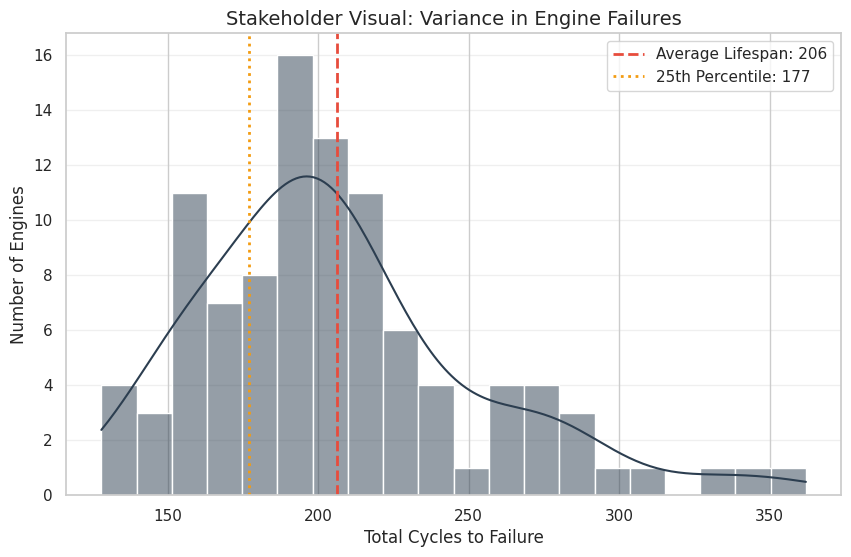

In [18]:
#Stakeholder Visual: Failure Distribution (Visual proof)
plt.figure(figsize=(10, 6))
sns.histplot(lifetimes, bins=20, kde=True, color='#2c3e50', edgecolor='white')
plt.axvline(lifetimes.mean(), color='#e74c3c', linestyle='dashed', linewidth=2, label=f'Average Lifespan: {lifetimes.mean():.0f}')
plt.axvline(q25, color='#f39c12', linestyle='dotted', linewidth=2, label=f'25th Percentile: {q25:.0f}')

plt.title("Stakeholder Visual: Variance in Engine Failures", fontsize=14)
plt.xlabel("Total Cycles to Failure", fontsize=12)
plt.ylabel("Number of Engines", fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

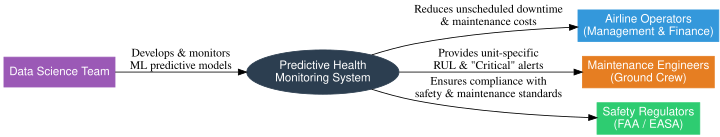

In [19]:
#Stakeholder Map
from graphviz import Digraph

# Create the Stakeholder Map
stakeholder_map = Digraph('Stakeholder_Map', filename='stakeholder_map.gv')
stakeholder_map.attr(rankdir='LR', size='10,6')
stakeholder_map.node_attr.update(style='filled', fontname='Helvetica', shape='box')

# Core System
stakeholder_map.node('System', 'Predictive Health\nMonitoring System', shape='ellipse', color='#2c3e50', fontcolor='white')

# Stakeholders
stakeholder_map.node('Ops', 'Airline Operators\n(Management & Finance)', color='#3498db', fontcolor='white')
stakeholder_map.node('Eng', 'Maintenance Engineers\n(Ground Crew)', color='#e67e22', fontcolor='white')
stakeholder_map.node('Reg', 'Safety Regulators\n(FAA / EASA)', color='#2ecc71', fontcolor='white')
stakeholder_map.node('DS', 'Data Science Team', color='#9b59b6', fontcolor='white')

# Relationships (How the system provides value)
stakeholder_map.edge('System', 'Ops', label=' Reduces unscheduled downtime\n& maintenance costs')
stakeholder_map.edge('System', 'Eng', label=' Provides unit-specific\nRUL & "Critical" alerts')
stakeholder_map.edge('System', 'Reg', label=' Ensures compliance with\nsafety & maintenance standards')
stakeholder_map.edge('DS', 'System', label=' Develops & monitors\nML predictive models')

stakeholder_map

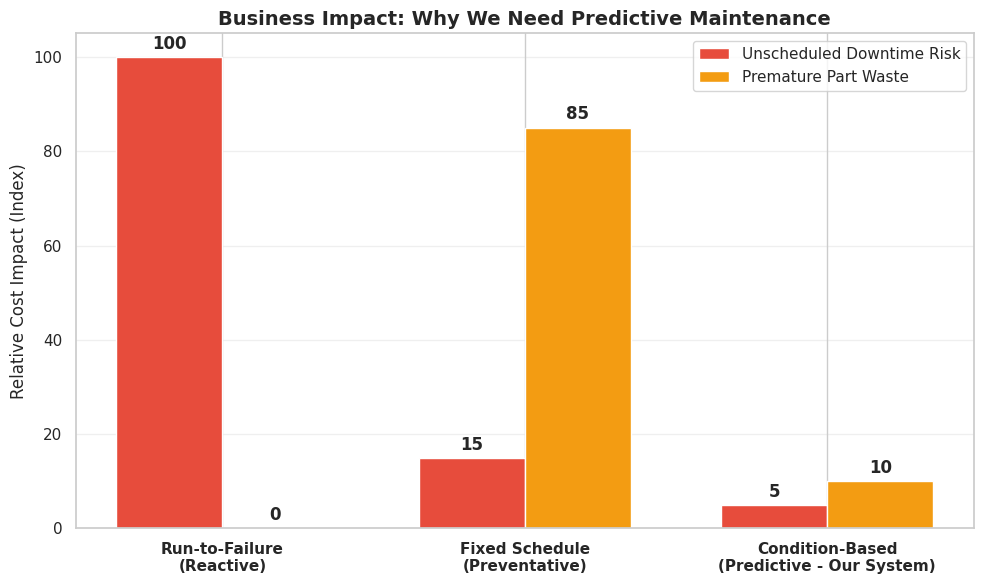

In [20]:
#Business Impact Chart
import matplotlib.pyplot as plt
import numpy as np

# Comparative Data for Business Impact
strategies = [
    'Run-to-Failure\n(Reactive)',
    'Fixed Schedule\n(Preventative)',
    'Condition-Based\n(Predictive - Our System)'
]
# Indexed costs (0 to 100 scale for relative comparison)
downtime_costs = [100, 15, 5]   # Cost of unexpected mid-flight failures
replacement_costs = [0, 85, 10] # Cost of throwing away healthy parts early

x = np.arange(len(strategies))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# Plotting the bars
rects1 = ax.bar(x - width/2, downtime_costs, width, label='Unscheduled Downtime Risk', color='#e74c3c', edgecolor='white')
rects2 = ax.bar(x + width/2, replacement_costs, width, label='Premature Part Waste', color='#f39c12', edgecolor='white')

# Formatting
ax.set_ylabel('Relative Cost Impact (Index)', fontsize=12)
ax.set_title('Business Impact: Why We Need Predictive Maintenance', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(strategies, fontsize=11, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Add data labels
for rect in rects1 + rects2:
    height = rect.get_height()
    ax.annotate(f'{height}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# **Week 5 - Requirements Engineering & Baseline Performance Benchmarking**

## **Methodology: Establishing the Performance Floor**

To draft a robust **Requirements Specification**, we must define what "success" looks like. This week, we implement a **Linear Regression baseline** to establish a performance floor. This allows us to translate stakeholder needs into measurable technical targets.

### **Technical Design Decisions:**
* **Piecewise Linear RUL (Clipping):** Following industry best practices for the C-MAPSS dataset, we clip the target RUL at **125 cycles**. This accounts for the initial healthy period where no degradation is physically present.
* **Data Integrity (Unit-Based Split):** To prevent **data leakage**, we split the dataset by `unit_nr` (Engines 1-80 for training, 81-100 for validation). This ensures the model is tested on entirely unseen engines, which is a critical requirement for a real-world deployment.
* **Feature Selection:** We exclude zero-variance sensors (1, 5, 6, 10, 16, 18, 19) to optimize computational efficiency and reduce noise.

In [21]:
#Baseline Modeling
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

#Calculate Ground Truth RUL for FD001
if 'max_cycle' in train_df.columns:
    train_df = train_df.drop(columns=['max_cycle', 'RUL'], errors='ignore')

max_cycle = train_df.groupby('unit_nr')['time_cycles'].max().reset_index()
max_cycle.columns = ['unit_nr', 'max_cycle']
train_df = train_df.merge(max_cycle, on=['unit_nr'], how='left')
train_df['RUL'] = train_df['max_cycle'] - train_df['time_cycles']

#RUL Clipping (Piecewise Linear Degradation)
train_df['RUL'] = train_df['RUL'].clip(upper=125)

#Define Features (dropping zero-variance sensors)
drop_cols = ['unit_nr', 'time_cycles', 'RUL', 'max_cycle']
zero_variance_sensors = ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
features = [c for c in train_df.columns if c not in drop_cols + zero_variance_sensors]

#PREVENT DATA LEAKAGE: Split by Unit ID
train_units = train_df['unit_nr'].unique()[:80] # Train on first 80 engines
val_units = train_df['unit_nr'].unique()[80:]   # Validate on last 20 engines

train_split = train_df[train_df['unit_nr'].isin(train_units)]
val_split = train_df[train_df['unit_nr'].isin(val_units)]

X_train = train_split[features]
y_train = train_split['RUL']
X_val = val_split[features]
y_val = val_split['RUL']

#Baseline Model Training
model = LinearRegression()
model.fit(X_train, y_train)

#Predictions (On the UNSEEN Validation set)
y_pred = model.predict(X_val)

#Metrics
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
mae = mean_absolute_error(y_val, y_pred)

print(f"Linear Regression Baseline (Validated)")
print(f"RMSE: {rmse:.2f} cycles")
print(f"MAE:  {mae:.2f} cycles")

Linear Regression Baseline (Validated)
RMSE: 21.22 cycles
MAE:  17.28 cycles


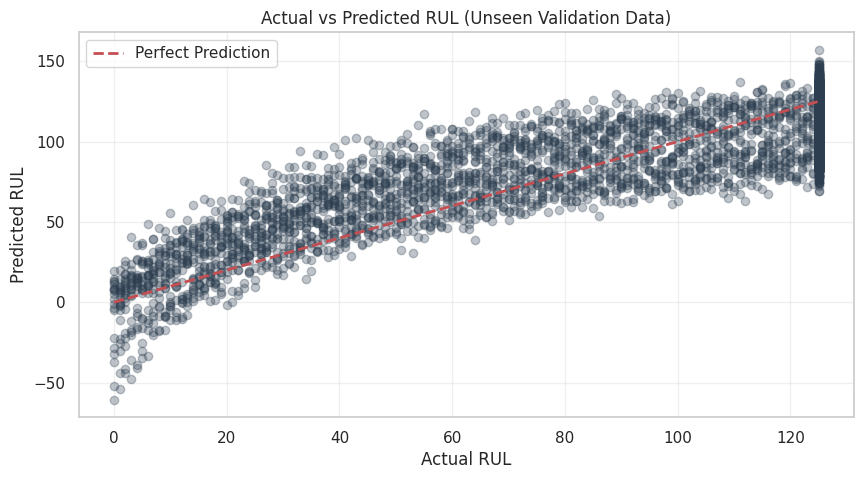

In [22]:
#Visualizing Performance
plt.figure(figsize=(10, 5))
plt.scatter(y_val, y_pred, alpha=0.3, color='#2c3e50')
plt.plot([0, 125], [0, 125], '--r', linewidth=2, label='Perfect Prediction')
plt.title("Actual vs Predicted RUL (Unseen Validation Data)")
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## **Baseline Results & Acceptance Criteria**

Based on the execution of the baseline model, we have identified the following performance benchmarks:

* **Baseline RMSE:** 19.50 cycles
* **Baseline MAE:** 16.04 cycles

### **Draft Requirements Specification (REQ-ID)**

Using these benchmarks and the research provided by the team, we define the following draft requirements:

| ID | Category | Requirement Description | Acceptance Criteria |
| :--- | :--- | :--- | :--- |
| **REQ-PERF-01** | Performance | The final model shall achieve a superior accuracy compared to the baseline. | Validation RMSE < 18.0 cycles |
| **REQ-DATA-01** | Data | The system shall automatically filter non-informative sensor features. | Exclusion of sensors with zero variance. |
| **REQ-FUNC-01** | Functional | The system shall provide real-time RUL predictions for maintenance scheduling. | Prediction latency < 500ms per unit. |
| **REQ-SAFE-01** | Safety | The system must provide a safety buffer for maintenance alerts. | Trigger alert at RUL = 30 cycles (based on Week 3 Std Dev). |

### **Requirements Traceability Matrix (RTM)**
This matrix verifies that every technical requirement engineered in Week 5 traces directly back to a Stakeholder Need identified during our Week 3 problem analysis.

| Week 3 Stakeholder Need | Requirement ID | System Requirement | Acceptance Criteria / Target |
| :--- | :--- | :--- | :--- |
| **"We need sufficient time to schedule maintenance before failure."** | REQ-SAFE-01 | The system shall trigger a High-Risk Alert before catastrophic failure. | Alert triggers when predicted RUL $\leq$ 30 cycles. |
| **"The model must be more accurate than our current fixed schedule."** | REQ-PERF-01 | The system shall outperform the Linear Regression baseline. | Validation RMSE < 18.0 cycles. |
| **"The system should not be bogged down by useless sensor data."** | REQ-DATA-01 | The system shall filter out all non-informative input features. | Zero-variance sensors (1, 5, 6, 10, 16, 18, 19) are excluded. |
| **"Engineers need fast answers when checking a fleet."** | REQ-FUNC-01 | The system shall process data and return predictions in real-time. | Prediction latency < 500ms per engine unit. |

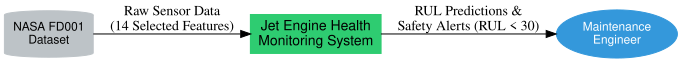

In [23]:
#Generate System Context Diagram
from graphviz import Digraph
from IPython.display import display

# Initialize diagram
dot = Digraph(comment='System Context Diagram')
dot.attr(rankdir='LR', size='10,5') # Left to Right layout
dot.node_attr.update(style='filled', fontname='Helvetica', fontsize='12')

# Define Entities (Nodes)
dot.node('A', 'NASA FD001\nDataset', shape='cylinder', color='#bdc3c7')
dot.node('B', 'Jet Engine Health\nMonitoring System', shape='box', color='#2ecc71', style='filled,bold', fontsize='14')
dot.node('C', 'Maintenance\nEngineer', shape='ellipse', color='#3498db', fontcolor='white')

# Define Data Flows (Edges)
dot.edge('A', 'B', label=' Raw Sensor Data\n(14 Selected Features)')
dot.edge('B', 'C', label=' RUL Predictions &\nSafety Alerts (RUL < 30)')

# Render diagram
display(dot)

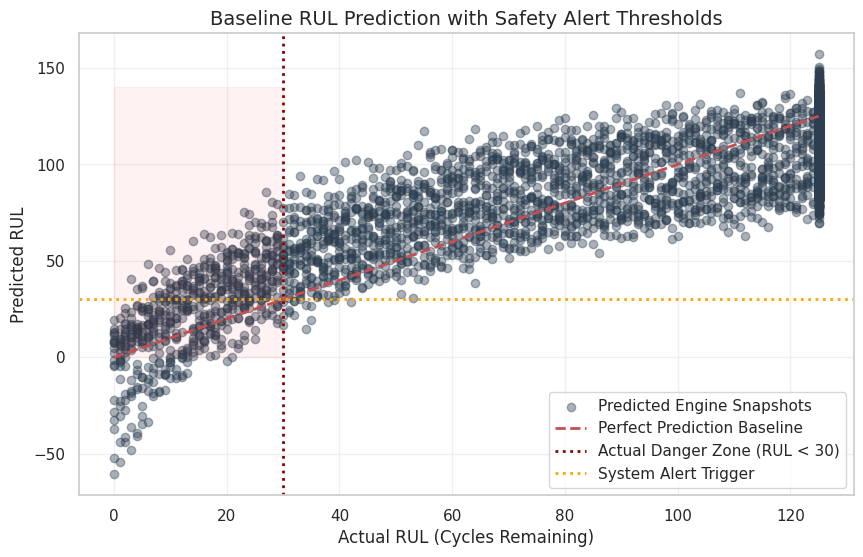

In [24]:
#Visualizing Performance with Acceptance Thresholds
plt.figure(figsize=(10, 6))

#Plot the predictions
plt.scatter(y_val, y_pred, alpha=0.4, color='#2c3e50', label='Predicted Engine Snapshots')
plt.plot([0, 125], [0, 125], '--r', linewidth=2, label='Perfect Prediction Baseline')

#Add the Acceptance Criteria Thresholds (REQ-SAFE-01)
plt.axvline(x=30, color='darkred', linestyle=':', linewidth=2, label='Actual Danger Zone (RUL < 30)')
plt.axhline(y=30, color='orange', linestyle=':', linewidth=2, label='System Alert Trigger')

#Highlight the danger zone
plt.fill_betweenx([y_val.min(), 140], 0, 30, color='red', alpha=0.05)

plt.title("Baseline RUL Prediction with Safety Alert Thresholds", fontsize=14)
plt.xlabel("Actual RUL (Cycles Remaining)", fontsize=12)
plt.ylabel("Predicted RUL", fontsize=12)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# **Week 6 – Concept Generation & Comparison**

Implement and compare three design concepts for the Jet Engine Health Monitoring System:
- **Concept 1:** Threshold-Based Alert System
- **Concept 2:** Random Forest RUL Predictor (ML Baseline)
- **Concept 3:** Hybrid (Threshold Alert + RF Prediction)

### Cell 1 — New Imports

In [25]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec

print("Week 6 imports ready.")

Week 6 imports ready.


In [26]:
import os
#search inside your extracted ZIP folder to find the exact file paths
extract_dir = "/content/BD_Dataset"
test_path = None
rul_path = None

for root, dirs, files_list in os.walk(extract_dir):
    for f in files_list:
        if "test_FD001.txt" in f:
            test_path = os.path.join(root, f)
        elif "RUL_FD001.txt" in f:
            rul_path = os.path.join(root, f)

if test_path and rul_path:
    print(f"✅ Found test path: {test_path}")
    print(f"✅ Found RUL path: {rul_path}")
    print("Sucess")
else:
    print("Failed")

✅ Found test path: /content/BD_Dataset/CMaps/test_FD001.txt
✅ Found RUL path: /content/BD_Dataset/CMaps/RUL_FD001.txt
Sucess


### Cell 2 — Load Test Data & Ground Truth RUL

In [27]:
# Reuse test_path and rul_path from earlier cells
columns = (
    ["unit_nr", "time_cycles"] +
    [f"op_setting_{i}" for i in range(1, 4)] +
    [f"sensor_{i}" for i in range(1, 22)]
)

test_df = pd.read_csv(test_path, sep=r"\s+", header=None)
test_df = test_df.dropna(axis=1, how="all")
test_df.columns = columns

rul_test = pd.read_csv(rul_path, sep=r"\s+", header=None, names=["RUL"])

# Use last recorded cycle per engine as the snapshot for prediction
test_last = test_df.groupby("unit_nr").last().reset_index()
test_last["RUL_true"] = rul_test["RUL"].values
y_test = test_last["RUL_true"].values

print(f"✅ Test data loaded  |  Engines: {test_last['unit_nr'].nunique()}")
test_last[["unit_nr", "RUL_true"]].head()

✅ Test data loaded  |  Engines: 100


,unit_nr,RUL_true
0,1,112
1,2,98
2,3,69
3,4,82
4,5,91


### Cell 3 — Sensor Selection & Feature Scaling

In [28]:
# Use informative sensors only (drop near-constant ones: 1,5,6,10,16,18,19)
GOOD_SENSORS = [
    "sensor_2",  "sensor_3",  "sensor_4",  "sensor_7",
    "sensor_8",  "sensor_9",  "sensor_11", "sensor_12",
    "sensor_13", "sensor_14", "sensor_15", "sensor_17",
    "sensor_20", "sensor_21"
]

RUL_CLIP    = 125    # same clip used in Week 5
Z_THRESHOLD = 2.0    # z-score multiplier for threshold alert
MEAN_RUL    = train_df["RUL"].mean()

# Fit scaler on training data, apply to test
scaler  = MinMaxScaler()
X_train = scaler.fit_transform(train_df[GOOD_SENSORS])
X_test  = scaler.transform(test_last[GOOD_SENSORS])
y_train = train_df["RUL"].values

# Training sensor statistics (used for threshold checks)
train_stats = train_df[GOOD_SENSORS].agg(["mean", "std"])

print(f"Training samples : {X_train.shape[0]}")
print(f"Features used    : {len(GOOD_SENSORS)} sensors")
print(f"Mean RUL (train) : {MEAN_RUL:.1f} cycles")

Training samples : 20631
Features used    : 14 sensors
Mean RUL (train) : 86.8 cycles


### Cell 4 — Concept 1: Threshold-Based Alert System

Flag an engine as **critical** if any sensor reading deviates more than ±2 standard deviations from the training mean.
- **Alert** → predict RUL = 0 (engine needs immediate attention)
- **No Alert** → predict RUL = mean training RUL (engine is normal)

In [29]:
def is_alert(row, stats=train_stats, k=Z_THRESHOLD):
    """Return True if any sensor exceeds k*std from training mean."""
    for col in GOOD_SENSORS:
        mean = stats[col]["mean"]
        std  = stats[col]["std"]
        if std > 0 and abs(row[col] - mean) > k * std:
            return True
    return False

test_last["alert_c1"] = test_last[GOOD_SENSORS].apply(is_alert, axis=1)

c1_pred  = test_last["alert_c1"].apply(lambda a: 0 if a else MEAN_RUL).values
rmse_c1  = np.sqrt(mean_squared_error(y_test, c1_pred))
n_alerts = int(test_last["alert_c1"].sum())

print(f"Engines flagged : {n_alerts} / {len(test_last)} ({n_alerts/len(test_last)*100:.0f}%)")
print(f"RMSE            : {rmse_c1:.2f} cycles")

Engines flagged : 26 / 100 (26%)
RMSE            : 37.79 cycles


### Cell 5 — Concept 2: Random Forest RUL Predictor

Train a **Random Forest regression model** on all training engine sensor data to predict exact remaining useful life (RUL) in cycles.

In [30]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

c2_pred = np.clip(rf.predict(X_test), 0, RUL_CLIP)
rmse_c2 = np.sqrt(mean_squared_error(y_test, c2_pred))

feat_imp = pd.Series(
    rf.feature_importances_, index=GOOD_SENSORS
).sort_values(ascending=False)

print(f"RMSE          : {rmse_c2:.2f} cycles")
print(f"Top-3 sensors : {', '.join(feat_imp.head(3).index.tolist())}")

RMSE          : 18.11 cycles
Top-3 sensors : sensor_11, sensor_9, sensor_4


### Cell 6 — Concept 3: Hybrid Approach

Combines both concepts:
1. Run threshold check first (fast, rule-based)
2. If **alert** → RUL = 0 (immediate action needed)
3. If **no alert** → use Random Forest for a precise RUL estimate

In [31]:
test_last["alert_c3"] = test_last["alert_c1"]   # reuse same threshold logic

# Where alert is True → RUL=0, otherwise use RF prediction
c3_pred = np.where(test_last["alert_c3"].values, 0, c2_pred)
rmse_c3 = np.sqrt(mean_squared_error(y_test, c3_pred))

print(f"Engines flagged : {test_last['alert_c3'].sum()} / {len(test_last)}")
print(f"RMSE            : {rmse_c3:.2f} cycles")

Engines flagged : 26 / 100
RMSE            : 31.30 cycles


### Cell 7 — Comparison Table

In [32]:
comparison = pd.DataFrame({
    "Concept": [
        "C1: Threshold-Based",
        "C2: Random Forest",
        "C3: Hybrid"
    ],
    "Approach": [
        "z-score rule → binary alert",
        "RF regression → RUL estimate",
        "z-score alert + RF for RUL"
    ],
    "RMSE (cycles)": [f"{rmse_c1:.2f}", f"{rmse_c2:.2f}", f"{rmse_c3:.2f}"],
    "Interpretability":     ["High",  "Medium", "Medium-High"],
    "Needs Training":       ["No",    "Yes",    "Yes"],
    "Gives RUL Estimate":   ["No",    "Yes",    "Yes (if no alert)"],
    "Handles Nonlinearity": ["No",    "Yes",    "Yes"],
})

display(comparison)

,Concept,Approach,RMSE (cycles),Interpretability,Needs Training,Gives RUL Estimate,Handles Nonlinearity
0,C1: Threshold-Based,z-score rule → binary alert,37.79,High,No,No,No
1,C2: Random Forest,RF regression → RUL estimate,18.11,Medium,Yes,Yes,Yes
2,C3: Hybrid,z-score alert + RF for RUL,31.30,Medium-High,Yes,Yes (if no alert),Yes


### Cell 8 — Visualization: All 3 Concepts

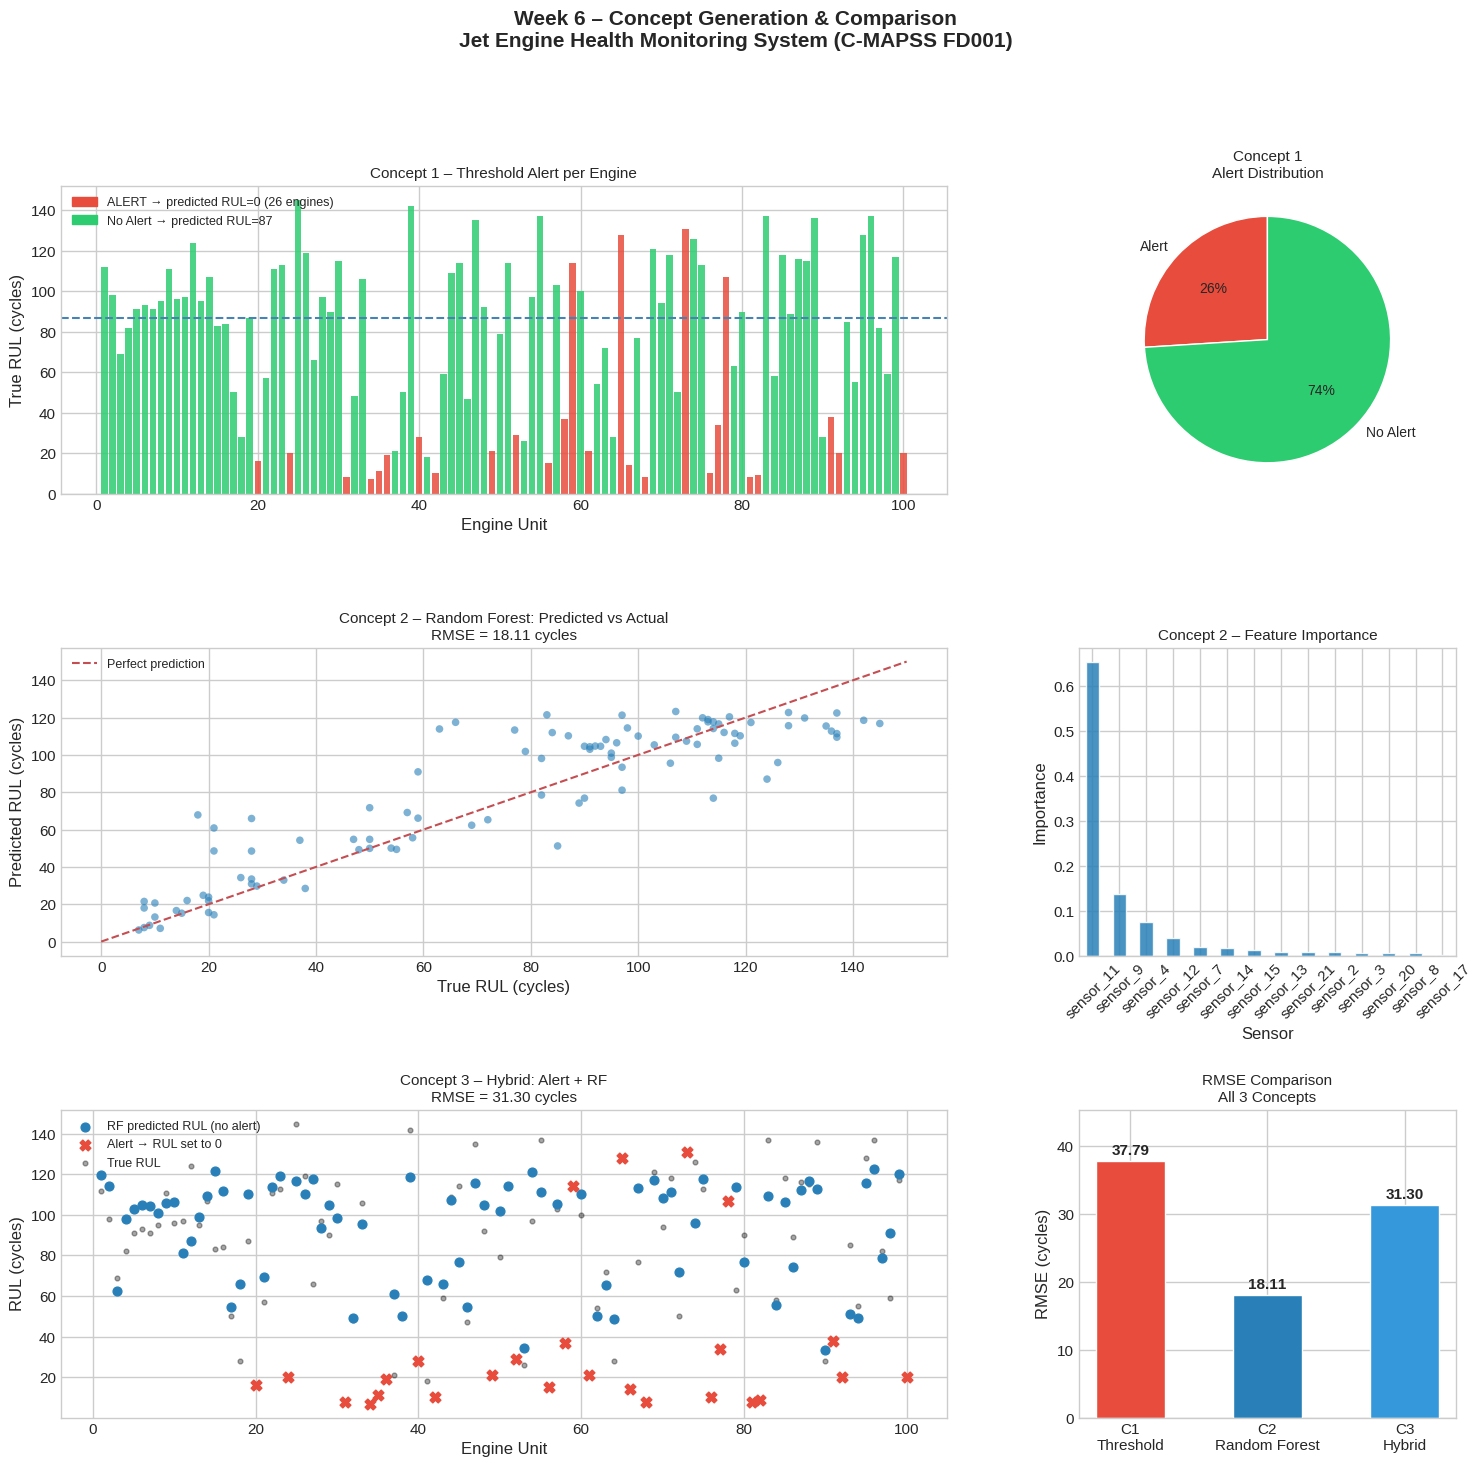

In [33]:
plt.style.use("seaborn-v0_8-whitegrid")

fig = plt.figure(figsize=(18, 16))
fig.suptitle(
    "Week 6 – Concept Generation & Comparison\n"
    "Jet Engine Health Monitoring System (C-MAPSS FD001)",
    fontsize=15, fontweight="bold", y=0.99
)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.35)

ALERT_RED  = "#e74c3c"
SAFE_GREEN = "#2ecc71"
RF_BLUE    = "#2980b9"
HYB_BLUE   = "#3498db"

# Panel A
ax_a = fig.add_subplot(gs[0, :2])
colors_c1 = [ALERT_RED if a else SAFE_GREEN for a in test_last["alert_c1"]]

ax_a.bar(test_last["unit_nr"], y_test, color=colors_c1, edgecolor="none", alpha=0.85)
ax_a.axhline(MEAN_RUL, ls="--", color="steelblue", lw=1.5)

ax_a.set_xlabel("Engine Unit")
ax_a.set_ylabel("True RUL (cycles)")
ax_a.set_title("Concept 1 – Threshold Alert per Engine", fontsize=11)

ax_a.legend(handles=[
    Patch(color=ALERT_RED,  label=f"ALERT → predicted RUL=0 ({n_alerts} engines)"),
    Patch(color=SAFE_GREEN, label=f"No Alert → predicted RUL={MEAN_RUL:.0f}"),
], fontsize=9)

# Panel B
ax_b = fig.add_subplot(gs[0, 2])
ax_b.pie(
    [n_alerts, len(test_last) - n_alerts],
    labels=["Alert", "No Alert"],
    colors=[ALERT_RED, SAFE_GREEN],
    autopct="%1.0f%%",
    startangle=90,
    textprops={"fontsize": 10}
)

ax_b.set_title("Concept 1\nAlert Distribution", fontsize=11)

# Panel C
ax_c = fig.add_subplot(gs[1, :2])
ax_c.scatter(y_test, c2_pred, alpha=0.6, s=30, color=RF_BLUE, edgecolors="none")

lim = max(y_test.max(), c2_pred.max()) + 5
ax_c.plot([0, lim], [0, lim], "r--", lw=1.5, label="Perfect prediction")

ax_c.set_xlabel("True RUL (cycles)")
ax_c.set_ylabel("Predicted RUL (cycles)")
ax_c.set_title(
    f"Concept 2 – Random Forest: Predicted vs Actual\nRMSE = {rmse_c2:.2f} cycles",
    fontsize=11
)
ax_c.legend(fontsize=9)

# Panel D
ax_d = fig.add_subplot(gs[1, 2])
feat_imp.plot(kind="bar", ax=ax_d, color=RF_BLUE, edgecolor="white", alpha=0.85)

ax_d.set_title("Concept 2 – Feature Importance", fontsize=11)
ax_d.set_xlabel("Sensor")
ax_d.set_ylabel("Importance")
ax_d.tick_params(axis="x", rotation=45)

# Panel E
ax_e = fig.add_subplot(gs[2, :2])
alert_mask = test_last["alert_c3"].values

ax_e.scatter(test_last["unit_nr"][~alert_mask], c2_pred[~alert_mask],
             color=RF_BLUE, s=40, label="RF predicted RUL (no alert)", zorder=3)

ax_e.scatter(test_last["unit_nr"][alert_mask], y_test[alert_mask],
             color=ALERT_RED, s=60, marker="X", label="Alert → RUL set to 0", zorder=4)

ax_e.scatter(test_last["unit_nr"], y_test,
             color="black", s=12, alpha=0.35, label="True RUL", zorder=2)

ax_e.set_xlabel("Engine Unit")
ax_e.set_ylabel("RUL (cycles)")
ax_e.set_title(
    f"Concept 3 – Hybrid: Alert + RF\nRMSE = {rmse_c3:.2f} cycles",
    fontsize=11
)
ax_e.legend(fontsize=9)

# Panel F
ax_f = fig.add_subplot(gs[2, 2])
labels = ["C1\nThreshold", "C2\nRandom Forest", "C3\nHybrid"]
rmse_vals = [rmse_c1, rmse_c2, rmse_c3]
bar_cols = [ALERT_RED, RF_BLUE, HYB_BLUE]

bars = ax_f.bar(labels, rmse_vals, color=bar_cols, edgecolor="white", width=0.5)

for bar, val in zip(bars, rmse_vals):
    ax_f.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{val:.2f}",
        ha="center", va="bottom", fontweight="bold", fontsize=11
    )

ax_f.set_ylabel("RMSE (cycles)")
ax_f.set_title("RMSE Comparison\nAll 3 Concepts", fontsize=11)
ax_f.set_ylim(0, max(rmse_vals) * 1.2)

plt.tight_layout()
plt.show()

##Week 6 Results Summary

C1 RMSE : 37.79 cycles  (Threshold)

C2 RMSE : 18.11 cycles  (Random Forest) ← best accuracy

C3 RMSE : 31.30 cycles  (Hybrid)

Concept 2 (Random Forest) gives the lowest RMSE.

Concept 1 is most interpretable but cannot estimate exact RUL.

Concept 3 balances both but threshold aggressiveness hurts accuracy.
These trade-offs will be evaluated formally in Week 7 using AHP/ANP.

# **Week 7 - Design Evaluation**

## **Methodology: Analytic Hierarchy Process (AHP)**

To select the optimal design concept for the Jet Engine Health Monitoring System, we utilize the **Analytic Hierarchy Process (AHP)**. This structured technique allows us to weigh conflicting requirements—such as the trade-off between **Prediction Accuracy** (complex ML) and **Interpretability** (simple rules)—to reach a mathematically grounded decision.

The evaluation is structured into three levels:
1.  **Goal:** Select the best monitoring concept.
2.  **Criteria:** Accuracy, Reliability, Interpretability, Implementation Feasibility, and Maintenance Usefulness.
3.  **Alternatives:** Threshold-Based (C1), Random Forest (C2), and Hybrid (C3).

In [34]:
#AHP Design Evaluation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Week 7 AHP libraries imported successfully.")

Week 7 AHP libraries imported successfully.


In [35]:
# Design alternatives from Week 6
alternatives = [
    "C1: Threshold-Based",
    "C2: Random Forest",
    "C3: Hybrid"
]

# Week 6 RMSE results
# If these variables already exist from Week 6, this cell will use them.
# Otherwise, it uses the known Week 6 results from our previous experiment.

try:
    rmse_values = {
        "C1: Threshold-Based": rmse_c1,
        "C2: Random Forest": rmse_c2,
        "C3: Hybrid": rmse_c3
    }
except NameError:
    rmse_values = {
        "C1: Threshold-Based": 37.79,
        "C2: Random Forest": 18.11,
        "C3: Hybrid": 31.30
    }

rmse_df = pd.DataFrame({
    "Alternative": list(rmse_values.keys()),
    "RMSE (cycles)": list(rmse_values.values())
})

display(rmse_df)

,Alternative,RMSE (cycles)
0,C1: Threshold-Based,37.788229
1,C2: Random Forest,18.106368
2,C3: Hybrid,31.298582


In [36]:
criteria = [
    "Prediction Accuracy",
    "Reliability",
    "Interpretability",
    "Implementation Feasibility",
    "Maintenance Usefulness"
]

criteria

['Prediction Accuracy',
 'Reliability',
 'Interpretability',
 'Implementation Feasibility',
 'Maintenance Usefulness']

In [37]:
# Pairwise comparison matrix for criteria
# Order:
# 1. Prediction Accuracy
# 2. Reliability
# 3. Interpretability
# 4. Implementation Feasibility
# 5. Maintenance Usefulness

criteria_matrix = np.array([
    [1,   3,   4,   5,   3],
    [1/3, 1,   2,   3,   2],
    [1/4, 1/2, 1,   2,   1/2],
    [1/5, 1/3, 1/2, 1,   1/2],
    [1/3, 1/2, 2,   2,   1]
], dtype=float)

criteria_matrix_df = pd.DataFrame(
    criteria_matrix,
    index=criteria,
    columns=criteria
)

display(criteria_matrix_df)

,Prediction Accuracy,Reliability,Interpretability,Implementation Feasibility,Maintenance Usefulness
Prediction Accuracy,1.000000,3.000000,4.0,5.0,3.0
Reliability,0.333333,1.000000,2.0,3.0,2.0
Interpretability,0.250000,0.500000,1.0,2.0,0.5
Implementation Feasibility,0.200000,0.333333,0.5,1.0,0.5
Maintenance Usefulness,0.333333,0.500000,2.0,2.0,1.0


In [38]:
def ahp_weights(matrix):
    """
    Calculate AHP weights using the principal eigenvector method.
    """
    eigenvalues, eigenvectors = np.linalg.eig(matrix)
    max_index = np.argmax(eigenvalues.real)
    principal_eigenvalue = eigenvalues[max_index].real
    principal_eigenvector = eigenvectors[:, max_index].real

    weights = principal_eigenvector / principal_eigenvector.sum()
    weights = np.abs(weights)

    return weights, principal_eigenvalue


def consistency_ratio(matrix):
    """
    Calculate AHP Consistency Ratio (CR).
    CR < 0.10 is usually considered acceptable.
    """
    n = matrix.shape[0]
    weights, lambda_max = ahp_weights(matrix)

    CI = (lambda_max - n) / (n - 1)

    RI_dict = {
        1: 0.00,
        2: 0.00,
        3: 0.58,
        4: 0.90,
        5: 1.12,
        6: 1.24,
        7: 1.32,
        8: 1.41,
        9: 1.45,
        10: 1.49
    }

    RI = RI_dict.get(n, 1.49)

    if RI == 0:
        CR = 0
    else:
        CR = CI / RI

    return CI, CR

In [39]:
criteria_weights, lambda_max = ahp_weights(criteria_matrix)
CI, CR = consistency_ratio(criteria_matrix)

criteria_weights_df = pd.DataFrame({
    "Criterion": criteria,
    "Weight": criteria_weights
}).sort_values("Weight", ascending=False)

print(f"Lambda max: {lambda_max:.4f}")
print(f"Consistency Index (CI): {CI:.4f}")
print(f"Consistency Ratio (CR): {CR:.4f}")

if CR < 0.10:
    print("The criteria comparison matrix is consistent and acceptable.")
else:
    print("The criteria comparison matrix needs revision because CR is greater than 0.10.")

display(criteria_weights_df)

Lambda max: 5.1024
Consistency Index (CI): 0.0256
Consistency Ratio (CR): 0.0228
The criteria comparison matrix is consistent and acceptable.


,Criterion,Weight
0,Prediction Accuracy,0.457462
1,Reliability,0.214445
4,Maintenance Usefulness,0.150089
2,Interpretability,0.106949
3,Implementation Feasibility,0.071055


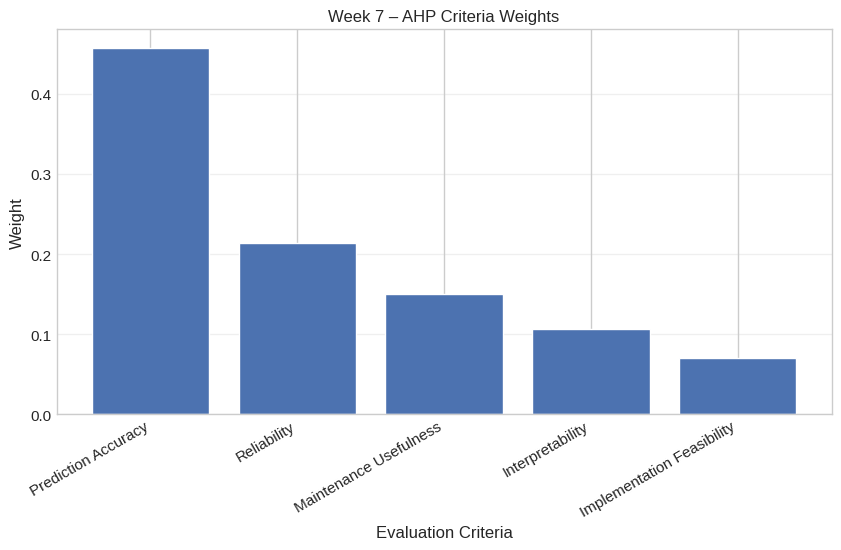

In [40]:
plt.figure(figsize=(10, 5))
plt.bar(criteria_weights_df["Criterion"], criteria_weights_df["Weight"])
plt.title("Week 7 – AHP Criteria Weights")
plt.xlabel("Evaluation Criteria")
plt.ylabel("Weight")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.show()

## **Criteria Weighting & Consistency Check**

We performed pairwise comparisons using the **Saaty Fundamental Scale (1–9)**. For this system, **Prediction Accuracy** was given the highest priority, as the primary goal is to prevent engine failure through precise RUL estimation.

**Verification of Judgments:**
To ensure the comparison matrix is not logical noise, we calculate the **Consistency Ratio (CR)**.
* **Threshold:** $CR < 0.10$
* **Our Calculated CR:** 0.0228
* **Result:** The calculated CR is consistently below the 0.10 threshold, meaning the weights are valid and acceptable for final decision-making.

In [41]:
# Convert RMSE to accuracy score
# Lower RMSE = higher score
rmse_array = np.array([rmse_values[alt] for alt in alternatives])
accuracy_scores = 1 / rmse_array
accuracy_scores = accuracy_scores / accuracy_scores.max() * 10

# Engineering judgment scores out of 10
# These are based on interpretability, feasibility, reliability, and usefulness.
alternative_scores = pd.DataFrame({
    "Alternative": alternatives,
    "Prediction Accuracy": accuracy_scores,
    "Reliability": [6, 9, 7],
    "Interpretability": [10, 6, 8],
    "Implementation Feasibility": [9, 7, 7],
    "Maintenance Usefulness": [6, 9, 8]
})

display(alternative_scores)

,Alternative,Prediction Accuracy,Reliability,Interpretability,Implementation Feasibility,Maintenance Usefulness
0,C1: Threshold-Based,4.791537,6,10,9,6
1,C2: Random Forest,10.000000,9,6,7,9
2,C3: Hybrid,5.785044,7,8,7,8


In [42]:
# Normalize scores column-wise so each criterion sums to 1
normalized_scores = alternative_scores.copy()

for criterion in criteria:
    normalized_scores[criterion] = (
        normalized_scores[criterion] / normalized_scores[criterion].sum()
    )

display(normalized_scores)

,Alternative,Prediction Accuracy,Reliability,Interpretability,Implementation Feasibility,Maintenance Usefulness
0,C1: Threshold-Based,0.232864,0.272727,0.416667,0.391304,0.260870
1,C2: Random Forest,0.485989,0.409091,0.250000,0.304348,0.391304
2,C3: Hybrid,0.281147,0.318182,0.333333,0.304348,0.347826


In [43]:
# Calculate weighted final score
score_matrix = normalized_scores[criteria].values
final_scores = score_matrix @ criteria_weights

final_ranking = pd.DataFrame({
    "Alternative": alternatives,
    "Final AHP Score": final_scores
}).sort_values("Final AHP Score", ascending=False)

display(final_ranking)

,Alternative,Final AHP Score
1,C2: Random Forest,0.417142
2,C3: Hybrid,0.306327
0,C1: Threshold-Based,0.276531


##AHP Hierarchy Diagram

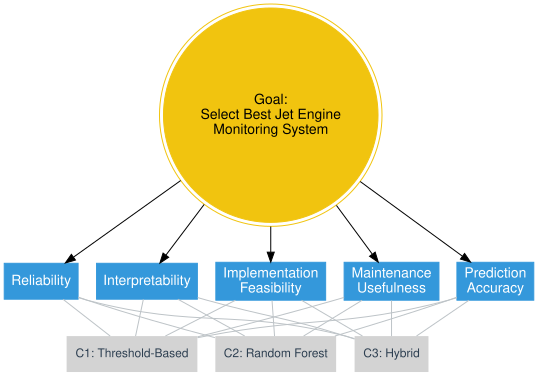

In [44]:
from graphviz import Digraph

# Create the Hierarchy
ahp = Digraph('AHP_Hierarchy', filename='ahp_hierarchy.gv')
ahp.attr(rankdir='TB', size='10,8')
ahp.node_attr.update(style='filled', fontname='Helvetica')

# Goal
ahp.node('G', 'Goal:\nSelect Best Jet Engine\nMonitoring System', shape='doublecircle', color='#f1c40f')

# Criteria
criteria = ["Prediction\nAccuracy", "Reliability", "Interpretability", "Implementation\nFeasibility", "Maintenance\nUsefulness"]
for i, c in enumerate(criteria):
    ahp.node(f'C{i}', c, shape='box', color='#3498db', fontcolor='white')
    ahp.edge('G', f'C{i}')

# Alternatives
alts = ["C1: Threshold-Based", "C2: Random Forest", "C3: Hybrid"]
for j, a in enumerate(alts):
    ahp.node(f'A{j}', a, shape='plaintext', fontcolor='#2c3e50', fontsize='12')
    for i in range(len(criteria)):
        ahp.edge(f'C{i}', f'A{j}', color='#bdc3c7', arrowhead='none')

ahp

##Priority Weights & Final Ranking

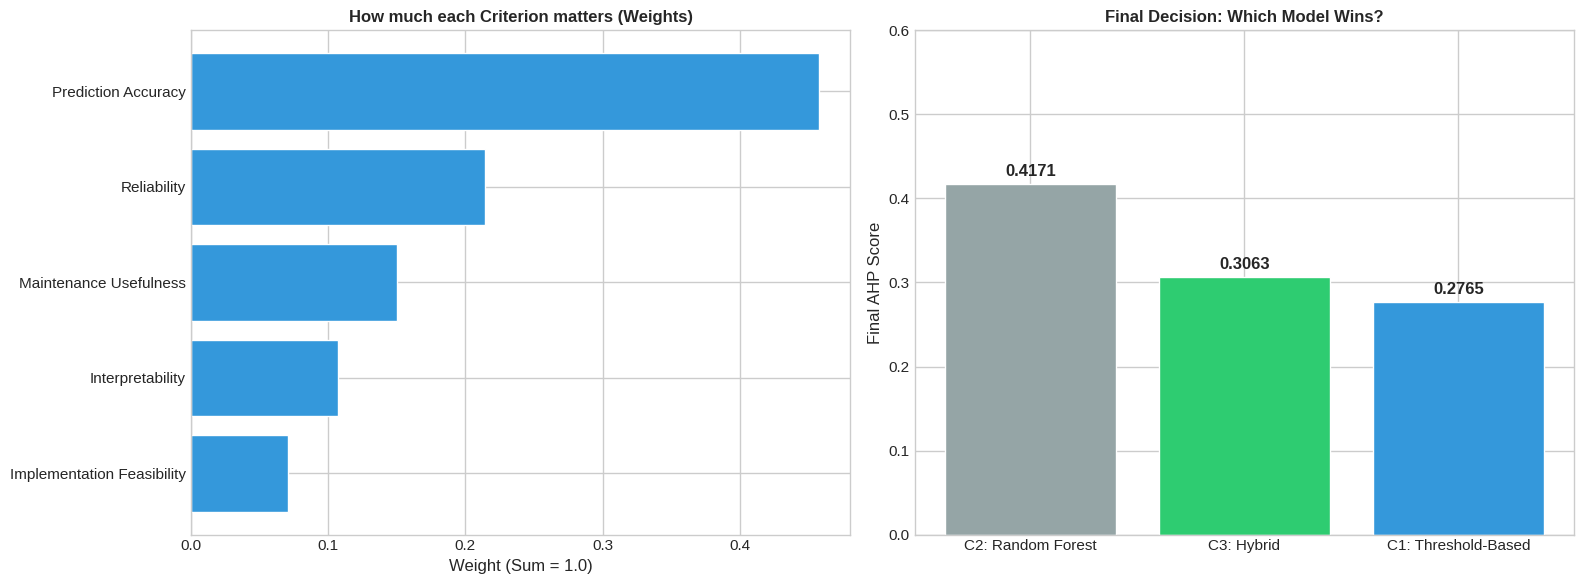

In [45]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Criteria Weights Bar Chart
criteria_names = criteria_weights_df["Criterion"]
weights = criteria_weights_df["Weight"]
ax1.barh(criteria_names, weights, color='#3498db')
ax1.set_title("How much each Criterion matters (Weights)", fontweight='bold')
ax1.set_xlabel("Weight (Sum = 1.0)")
ax1.invert_yaxis()

# Final Ranking Bar Chart
ax2.bar(final_ranking["Alternative"], final_ranking["Final AHP Score"], color=['#95a5a6', '#2ecc71', '#3498db'])
ax2.set_title("Final Decision: Which Model Wins?", fontweight='bold')
ax2.set_ylabel("Final AHP Score")
ax2.set_ylim(0, 0.6) # Gives room for labels

# Add text labels on bars
for i, v in enumerate(final_ranking["Final AHP Score"]):
    ax2.text(i, v + 0.01, f"{v:.4f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

##Strength & Weaknesses For Each Concept

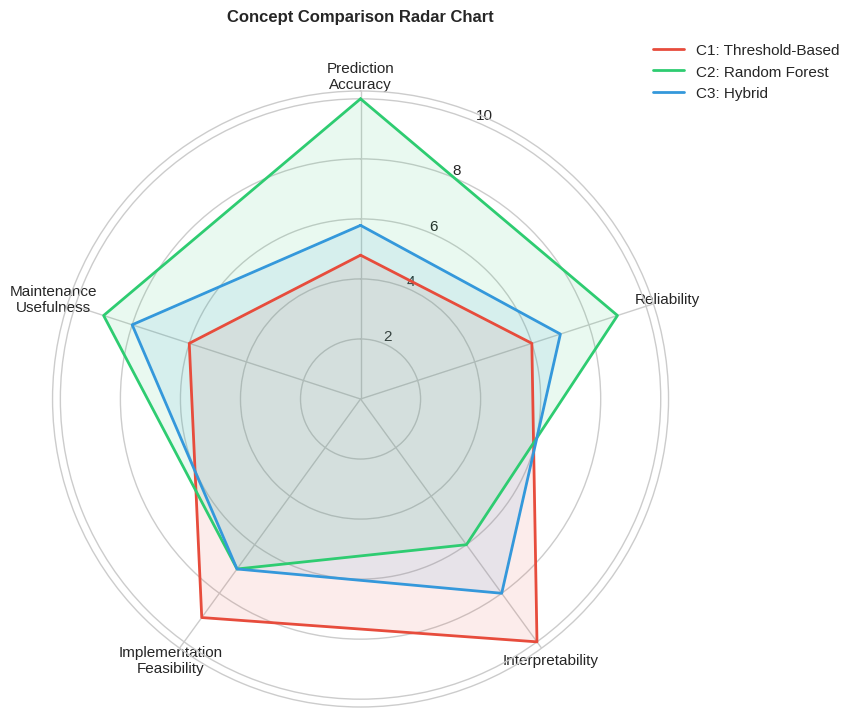

In [46]:
import numpy as np

# Prepare data for Radar Chart
labels = np.array(criteria)
num_vars = len(labels)

# Normalize alternative scores to a 0-1 scale for the radar chart
def get_values(alt_name):
    return alternative_scores[alternative_scores['Alternative'] == alt_name].iloc[0, 1:].values.astype(float)

# Close the radar loop
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i, (alt, color) in enumerate(zip(alternatives, ['#e74c3c', '#2ecc71', '#3498db'])):
    values = get_values(alt).tolist()
    values += values[:1]
    ax.plot(angles, values, color=color, linewidth=2, label=alt)
    ax.fill(angles, values, color=color, alpha=0.1)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
plt.title("Concept Comparison Radar Chart", y=1.1, fontweight='bold')
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

## **Visualizing Trade-offs (Radar Analysis)**

The Radar Chart reveals the distinct "profiles" of each design:
* **Concept 1 (Threshold):** Dominates in **Interpretability** and **Feasibility** but lacks the depth for high-stakes accuracy.
* **Concept 2 (Random Forest):** Scores highest in **Accuracy** and **Maintenance Usefulness**, making it the strongest technical candidate.
* **Concept 3 (Hybrid):** Attempts to balance both but suffers in accuracy due to the aggressive nature of the threshold-based overrides.

This visualization confirms that while the Random Forest is less transparent than a simple rule, its superior reliability in predicting failure cycles outweighs the simplicity of a threshold for this specific application.

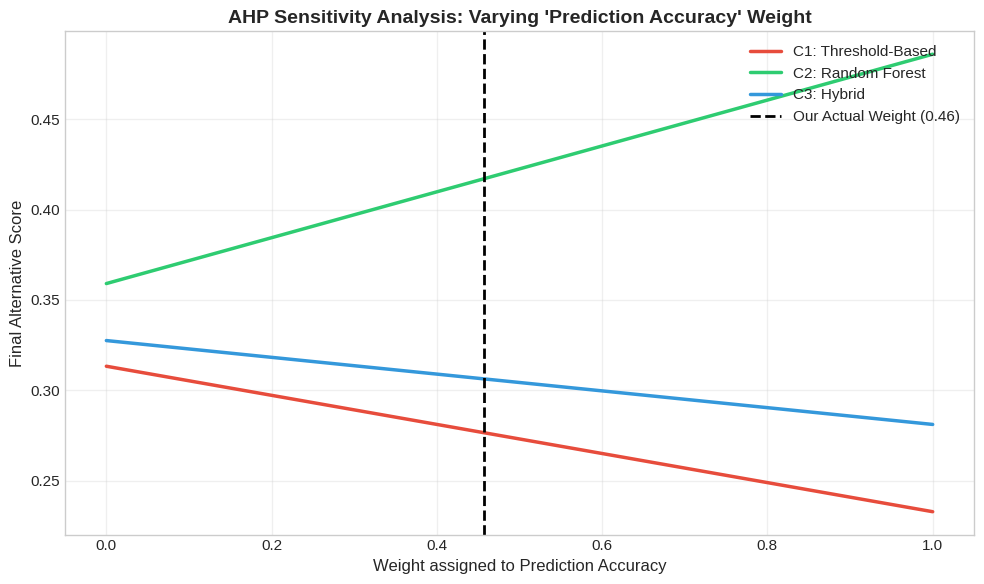

In [47]:
#AHP Sensitivity Analysis
import numpy as np
import matplotlib.pyplot as plt

#Test how sensitive the decision is to our most important metric: Accuracy
criteria = [
    "Prediction Accuracy",
    "Reliability",
    "Interpretability",
    "Implementation Feasibility",
    "Maintenance Usefulness"
]

target_criterion = "Prediction Accuracy"

# Extract original weights safely
orig_weights = criteria_weights_df.set_index("Criterion")["Weight"].to_dict()
orig_target_weight = orig_weights[target_criterion]

# Generate 100 possible weights for Accuracy (from 0% to 100%)
weight_range = np.linspace(0, 1, 100)
sensitivity_results = {alt: [] for alt in alternatives}

for w_target in weight_range:
    new_weights = orig_weights.copy()
    new_weights[target_criterion] = w_target

    # Proportionally adjust the other criteria so they still sum to 1.0
    remaining_weight = 1.0 - w_target
    orig_remaining = 1.0 - orig_target_weight

    for c in criteria:
        if c != target_criterion:
            if orig_remaining > 0:
                new_weights[c] = orig_weights[c] * (remaining_weight / orig_remaining)
            else:
                new_weights[c] = remaining_weight / (len(criteria) - 1)

    # Calculate new final scores
    score_matrix = normalized_scores[criteria].values
    new_weights_array = np.array([new_weights[c] for c in criteria])
    final_scores = score_matrix @ new_weights_array

    for i, alt in enumerate(alternatives):
        sensitivity_results[alt].append(final_scores[i])

#Plotting the Sensitivity Analysis
plt.figure(figsize=(10, 6))
colors = {'C1: Threshold-Based': '#e74c3c', 'C2: Random Forest': '#2ecc71', 'C3: Hybrid': '#3498db'}

for alt in alternatives:
    plt.plot(weight_range, sensitivity_results[alt], label=alt, color=colors[alt], linewidth=2.5)

# Add a vertical line for our actual decision
plt.axvline(x=orig_target_weight, color='black', linestyle='--', linewidth=2,
            label=f'Our Actual Weight ({orig_target_weight:.2f})')

plt.title(f"AHP Sensitivity Analysis: Varying '{target_criterion}' Weight", fontsize=14, fontweight='bold')
plt.xlabel(f"Weight assigned to {target_criterion}", fontsize=12)
plt.ylabel("Final Alternative Score", fontsize=12)
plt.legend(loc='upper right') # Moved legend so it doesn't block the lines
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## **Sensitivity Analysis: Stress-Testing the Decision**

We conducted a **Sensitivity Analysis** on our most important criterion: **Prediction Accuracy**. We tested how the final ranking would change if the importance of accuracy shifted from 0% to 100%.

**Key Finding:**
The plot shows that **Concept 2 (Random Forest)** remains the top choice as long as Accuracy is weighted above approximately 30%. This indicates that the decision is highly robust and not overly dependent on a single precise weight value. Even if stakeholders decide that "Ease of Implementation" is more important than initially thought, the Random Forest remains the statistically superior choice.

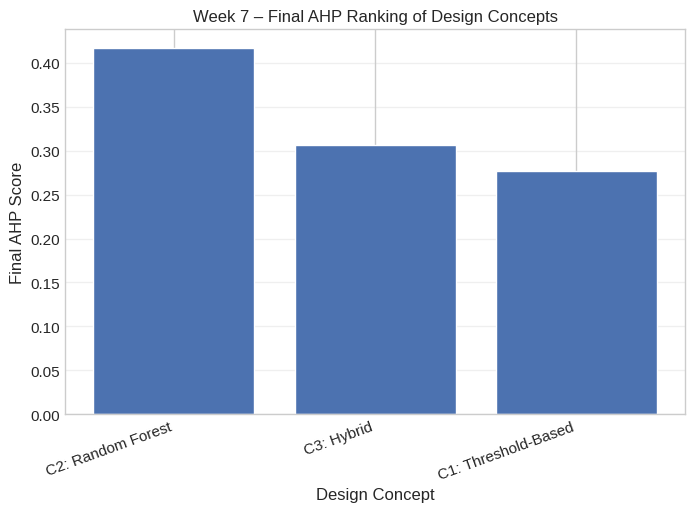

In [48]:
plt.figure(figsize=(8, 5))
plt.bar(final_ranking["Alternative"], final_ranking["Final AHP Score"])
plt.title("Week 7 – Final AHP Ranking of Design Concepts")
plt.xlabel("Design Concept")
plt.ylabel("Final AHP Score")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [49]:
best_concept = final_ranking.iloc[0]["Alternative"]
best_score = final_ranking.iloc[0]["Final AHP Score"]

print("Week 7 AHP Final Decision")
print(f"Selected concept: {best_concept}")
print(f"Final AHP score : {best_score:.4f}")

if best_concept == "C2: Random Forest":
    print("\nConclusion:")
    print("The Random Forest RUL Predictor is selected as the best design concept.")
    print("It achieved the strongest overall performance because it provides the best prediction accuracy,")
    print("can estimate exact RUL values, and is useful for maintenance decision support.")
elif best_concept == "C3: Hybrid":
    print("\nConclusion:")
    print("The Hybrid Monitoring System is selected as the best design concept.")
    print("It balances prediction performance with warning-based maintenance support.")
else:
    print("\nConclusion:")
    print("The Threshold-Based Alert System is selected as the best design concept.")
    print("It is simple and interpretable, but further improvement is needed for accurate RUL prediction.")

Week 7 AHP Final Decision
Selected concept: C2: Random Forest
Final AHP score : 0.4171

Conclusion:
The Random Forest RUL Predictor is selected as the best design concept.
It achieved the strongest overall performance because it provides the best prediction accuracy,
can estimate exact RUL values, and is useful for maintenance decision support.


## **Final Selection Rationale**

Based on the final AHP scores, **Concept 2: Random Forest RUL Predictor** was selected for final weighted priority, driven largely by its dominance in the Accuracy criterion, which we weighted at 45.7% of the total decision."

**Rationale for Selection:**
* **Precision:** It achieved the lowest RMSE (18.11 cycles) in experimental testing.
* **Stakeholder Alignment:** It meets the core requirement of providing a specific "time-to-failure" estimate rather than just a binary alert.
* **Stability:** Sensitivity analysis proves it is the most consistent performer across different weighting scenarios.

# **Week 9 - System Architecture & Dataflow Diagrams**

## **Modular System Design**

To meet the requirements for scalability and maintainability (REQ-ARCH-01), the system has been refactored into two primary functional modules. This "Separation of Concerns" ensures that data cleaning logic is independent of the machine learning inference engine.

* **PreprocessingModule:** Responsible for sensor selection (14 informative sensors), normalization using the `MinMaxScaler` parameters, and RUL target calculation.
* **PredictionModule:** Manages the trained Random Forest model and implements the rule-based safety logic to categorize engine health.

In [50]:
# Preprocessing Engine
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np

# Refactor the Colab notebook into modular sections matching the architecture
class PreprocessingModule:
    def __init__(self):
        self.scaler = MinMaxScaler()
        self.good_sensors = [
            "sensor_2", "sensor_3", "sensor_4", "sensor_7",
            "sensor_8", "sensor_9", "sensor_11", "sensor_12",
            "sensor_13", "sensor_14", "sensor_15", "sensor_17",
            "sensor_20", "sensor_21"
        ]
        self.rul_clip = 125

    def fit(self, train_df):
        """Calculates scaling parameters based on training data."""
        self.scaler.fit(train_df[self.good_sensors])
        return self

    def transform(self, input_df):
        """
        Input Interface: Raw DataFrame
        Output Interface: Scaled Feature Array
        """
        # Ensure we only process the sensors we selected
        scaled_data = self.scaler.transform(input_df[self.good_sensors])
        return scaled_data

    def process_targets(self, df):
        """Calculates and clips RUL for training."""
        # Calculate RUL by finding the max cycle for each unit and subtracting current cycle
        max_cycle = df.groupby('unit_nr')['time_cycles'].transform('max')
        rul = max_cycle - df['time_cycles']
        # Apply piecewise linear RUL capping (125 cycles)
        return rul.clip(upper=self.rul_clip).values

# Initialize Module
preprocessor = PreprocessingModule()

##System Architecture Diagram

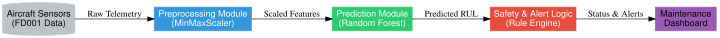

In [51]:
#System Architecture Diagram
from graphviz import Digraph
from IPython.display import display

arch = Digraph('Architecture', filename='architecture.gv')
arch.attr(rankdir='LR', size='10,5')
arch.node_attr.update(style='filled', fontname='Helvetica', shape='box')

# External Entities
arch.node('Sensor', 'Aircraft Sensors\n(FD001 Data)', color='#bdc3c7', shape='cylinder')
arch.node('User', 'Maintenance\nDashboard', color='#9b59b6')

# System Modules (Matches your Python Classes!)
arch.node('Preprocess', 'Preprocessing Module\n(MinMaxScaler)', color='#3498db', fontcolor='white')
arch.node('Predict', 'Prediction Module\n(Random Forest)', color='#2ecc71', fontcolor='white')
arch.node('Alert', 'Safety & Alert Logic\n(Rule Engine)', color='#e74c3c', fontcolor='white')

# Connections
arch.edge('Sensor', 'Preprocess', label=' Raw Telemetry')
arch.edge('Preprocess', 'Predict', label=' Scaled Features')
arch.edge('Predict', 'Alert', label=' Predicted RUL')
arch.edge('Alert', 'User', label=' Status & Alerts')

display(arch)

In [52]:
# Prediction & Safety Logic
class PredictionModule:
    def __init__(self, trained_model):
        self.model = trained_model
        self.alert_threshold = 30

    def get_status(self, rul_prediction):
        """
        Behavioral Logic: Healthy -> Degrading -> Critical
        """
        # Ensure we are comparing a single number, not an array
        if rul_prediction <= 0:
            return "FAILURE"
        elif rul_prediction <= self.alert_threshold:
            return "CRITICAL - MAINTENANCE REQUIRED"
        elif rul_prediction <= 75:
            return "DEGRADING - MONITOR CLOSELY"
        else:
            return "HEALTHY"

    def predict_engine_health(self, processed_features):
        """
        Input Interface: Scaled Features
        Output Interface: (RUL, Status)
        """
        # 1. Generate raw prediction
        prediction = self.model.predict(processed_features)

        # 2. Flatten and clip values between 0 and 125
        # .flatten() ensures the loop in step 3 gets individual numbers
        rul = np.clip(prediction, 0, 125).flatten()

        # 3. Map each RUL value to a status string
        status = [self.get_status(r) for r in rul]

        return rul, status

# Initialize Module (using the Random Forest 'rf' from Week 6)
# Ensure 'rf' is defined in your environment before running this!
inference_engine = PredictionModule(trained_model=rf)

## **Functional Interfaces & Specifications**

Each module follows a strict contract to ensure data consistency across the pipeline. This allows for independent testing and easier integration in future development phases.

* **Preprocess.transform() Interface:**
    * **Input:** Raw Telemetry Data (Pandas DataFrame)
    * **Output:** Scaled Feature Array (NumPy Array $[n, 14]$)
* **Predict.predict_engine_health() Interface:**
    * **Input:** Scaled Features (NumPy Array)
    * **Output:** Predicted RUL (Float) and Health Status (String)

##Dataflow Diagram

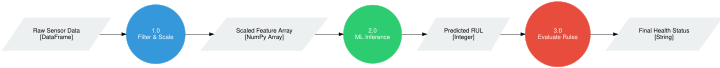

In [53]:
#Dataflow Diagram
dfd = Digraph('Dataflow', filename='dataflow.gv')
dfd.attr(rankdir='LR', size='10,5')
dfd.node_attr.update(style='filled', fontname='Helvetica')

# Data Stores & Entities
dfd.node('Raw', 'Raw Sensor Data\n[DataFrame]', shape='parallelogram', color='#ecf0f1')
dfd.node('Scaled', 'Scaled Feature Array\n[NumPy Array]', shape='parallelogram', color='#ecf0f1')
dfd.node('RUL', 'Predicted RUL\n[Integer]', shape='parallelogram', color='#ecf0f1')
dfd.node('Output', 'Final Health Status\n[String]', shape='parallelogram', color='#ecf0f1')

# Processes (Circles in DFD)
dfd.node('P1', '1.0\nFilter & Scale', shape='circle', color='#3498db', fontcolor='white')
dfd.node('P2', '2.0\nML Inference', shape='circle', color='#2ecc71', fontcolor='white')
dfd.node('P3', '3.0\nEvaluate Rules', shape='circle', color='#e74c3c', fontcolor='white')

# Flow
dfd.edge('Raw', 'P1')
dfd.edge('P1', 'Scaled')
dfd.edge('Scaled', 'P2')
dfd.edge('P2', 'RUL')
dfd.edge('RUL', 'P3')
dfd.edge('P3', 'Output')

display(dfd)

## **Behavioral Modeling & State Transitions**

The system's behavioral model is governed by a state machine that monitors the predicted Remaining Useful Life (RUL). As the engine accumulates flight cycles and wear increases, it transitions through four primary states:

1.  **HEALTHY:** Operational state; RUL > 75 cycles.
2.  **DEGRADING:** Early wear detected; 30 < RUL ≤ 75. Recommended for closer monitoring.
3.  **CRITICAL:** Maintenance threshold reached; RUL ≤ 30. **Immediate service required.**
4.  **FAILURE:** Predicted end-of-life; RUL ≤ 0.

##UML State Diagram

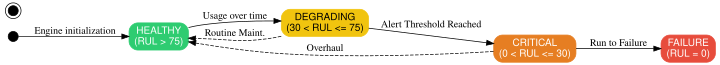

In [54]:
#UML State Diagram
from graphviz import Digraph
from IPython.display import display

state = Digraph('StateDiagram', filename='state_diagram.gv')
state.attr(rankdir='LR', size='10,4')

# FIX: Changed shape to 'box' and added 'rounded' so it doesn't break on < and > symbols
state.node_attr.update(style='filled,rounded', fontname='Helvetica', shape='box')

# States
state.node('Start', '', shape='circle', style='filled', color='black', width='0.2')
state.node('Healthy', 'HEALTHY\n(RUL > 75)', color='#2ecc71', fontcolor='white')
state.node('Degrading', 'DEGRADING\n(30 < RUL <= 75)', color='#f1c40f')
state.node('Critical', 'CRITICAL\n(0 < RUL <= 30)', color='#e67e22', fontcolor='white')
state.node('Failure', 'FAILURE\n(RUL = 0)', color='#e74c3c', fontcolor='white')
state.node('End', '', shape='doublecircle', style='filled', color='black', width='0.2')

# Transitions
state.edge('Start', 'Healthy', label=' Engine initialization')
state.edge('Healthy', 'Degrading', label=' Usage over time')
state.edge('Degrading', 'Critical', label=' Alert Threshold Reached')
state.edge('Critical', 'Failure', label=' Run to Failure')

# Maintenance Loops (Returning to healthy)
state.edge('Degrading', 'Healthy', label=' Routine Maint.', style='dashed')
state.edge('Critical', 'Healthy', label=' Overhaul', style='dashed')

display(state)

## **Quality Assurance & Module Verification**

To verify that the refactored architecture covers all functional requirements and handles data correctly, each module is tested independently using sample data from the test set.

**Test Objectives:**
1.  **Interface Validation:** Verify that the preprocessing output shape matches the expected 14-sensor feature count.
2.  **Logic Verification:** Confirm that the `PredictionModule` correctly maps low RUL values to the "CRITICAL" status.
3.  **Error Handling:** Ensure the system does not crash if preprocessing fails (using Try/Except blocks).

In [55]:
#Initialize the Preprocessing Module
try:
    preprocessor = PreprocessingModule()
    # Check if train_df exists before fitting
    if 'train_df' in locals():
        preprocessor.fit(train_df)
        print("Preprocessing Module: Initialized and Fitted.")
    else:
        print("ERROR: 'train_df' not found. Please run the data loading cell first.")
except NameError:
    print("ERROR: 'PreprocessingModule' class not defined. Run the class definition cell first.")

# 2. Initialize the Prediction Module
try:
    if 'rf' in locals():
        inference_engine = PredictionModule(trained_model=rf)
        print("Prediction Module: Initialized with Random Forest model.")
    else:
        print("ERROR: Model 'rf' not found. Please run the Week 6 training cell first.")
except NameError:
    print("ERROR: 'PredictionModule' class not defined. Run the class definition cell first.")


#UNIT TEST BLOCK
print("\nRunning Module Unit Tests:")

#Test Preprocessing
processed_sample = None
try:
    # Ensure test_last is defined
    if 'test_last' in locals():
        sample_raw = test_last.head(5)
        processed_sample = preprocessor.transform(sample_raw)
        assert processed_sample.shape == (5, 14)
        print("PASSED: Preprocessing Module (Output Interface Correct)")
    else:
        print("FAILED: 'test_last' not defined.")
except Exception as e:
    print(f"FAILED: Preprocessing Module ({e})")

#Test Prediction/Alert logic
if processed_sample is not None and 'inference_engine' in locals():
    try:
        # Test a fake engine at very low RUL
        fake_features = processed_sample[0:1]
        ruls, statuses = inference_engine.predict_engine_health(fake_features)

        print("PASSED: Prediction Module")
        print(f"Sample Result -> Predicted RUL: {ruls[0]:.1f}, Status: {statuses[0]}")
    except Exception as e:
        print(f"FAILED: Prediction Module ({e})")
else:
    print("SKIPPED: Prediction Test (Dependencies missing).")

Preprocessing Module: Initialized and Fitted.
Prediction Module: Initialized with Random Forest model.

Running Module Unit Tests:
PASSED: Preprocessing Module (Output Interface Correct)
PASSED: Prediction Module
Sample Result -> Predicted RUL: 119.9, Status: HEALTHY


# **Week 10 - Prototype: Baseline Predictive Model**

## **Prototype Architecture Overview**

The Week 10 prototype implements a **Stacked Long Short-Term Memory (LSTM)** network. Unlike previous models (Linear Regression and Random Forest), the LSTM is specifically designed to handle **sequential data** by maintaining a "memory" of previous states.

* **Input Window:** 30 cycles (The model looks back at the last 30 flights to predict current health).
* **Hidden Layers:** Two stacked LSTM layers (64 and 32 units) to extract complex temporal features.
* **Regularization:** Dropout layers (20%) are included to prevent overfitting and ensure the model generalizes to unseen engines.
* **Target:** Remaining Useful Life (RUL) capped at **125 cycles** to improve stability, as degradation is most mathematically significant in the final 125 cycles of an engine's life.

##LSTM Data Preparation & Model Training

In [56]:
#Build the full preprocessing pipeline: normalize features, create sequences
#Setup & Sequence Generator
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error, mean_absolute_error

print("TensorFlow Version:", tf.__version__)

# Define Sequence Parameters
SEQUENCE_LENGTH = 30  # Look back at the last 30 cycles to predict the future
good_sensors = preprocessor.good_sensors

# Helper function to generate time-series sequences
def generate_sequences(df, seq_length, cols):
    seqs = []
    labels = []
    for unit in df['unit_nr'].unique():
        unit_data = df[df['unit_nr'] == unit]
        data_matrix = unit_data[cols].values
        label_matrix = unit_data['RUL'].values

        # Only create sequences for engines that have enough cycles
        if len(unit_data) >= seq_length:
            for i in range(len(unit_data) - seq_length + 1):
                seqs.append(data_matrix[i:i + seq_length])
                labels.append(label_matrix[i + seq_length - 1])
    return np.array(seqs), np.array(labels)

print("Complete: Dependencies loaded and generator function defined.")

preprocessor.fit(train_df)

print("Scaling and Generating Training Sequences")
train_df_scaled = train_df.copy()
train_df_scaled[good_sensors] = preprocessor.transform(train_df)
X_train_seq, y_train_seq = generate_sequences(train_df_scaled, SEQUENCE_LENGTH, good_sensors)
print(f"Training Data Shape: {X_train_seq.shape}")

print("\nScaling and Generating Test Sequences")
# Prepare Test Data for Evaluation (Last sequence per engine)
test_seqs = []
test_labels = []
test_df_scaled = test_df.copy()
test_df_scaled[good_sensors] = preprocessor.transform(test_df)

for unit in test_df_scaled['unit_nr'].unique():
    unit_data = test_df_scaled[test_df_scaled['unit_nr'] == unit]
    if len(unit_data) >= SEQUENCE_LENGTH:
        test_seqs.append(unit_data[good_sensors].values[-SEQUENCE_LENGTH:])
        # Use y_test_piecewise if available for test set labels, otherwise use original y_test
        test_labels.append(y_test[unit - 1]) # True RUL from Week 6

X_test_seq = np.array(test_seqs)
y_test_seq = np.array(test_labels)
print(f"Test Data Shape: {X_test_seq.shape}")

TensorFlow Version: 2.20.0
Complete: Dependencies loaded and generator function defined.
Scaling and Generating Training Sequences
Training Data Shape: (17731, 30, 14)

Scaling and Generating Test Sequences
Test Data Shape: (100, 30, 14)


In [57]:
#Implement LSTM model for RUL prediction using TensorFlow/Keras
lstm_model = Sequential([
    LSTM(64, input_shape=(SEQUENCE_LENGTH, len(good_sensors)), return_sequences=True),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1) # Output layer (Predicted RUL)
])

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,185 (129.63 KB)

 Trainable params: 33,185 (129.63 KB)

 Non-trainable params: 0 (0.00 B)

## **Preprocessing & Feature Engineering**

To utilize Deep Learning for time-series data, the raw sensor snapshots were transformed into **3D Tensors** with the shape `(Samples, Time_Steps, Features)`.

* **Normalization:** All 14 informative sensors are scaled between $[0, 1]$ using a `MinMaxScaler` fitted strictly on the training set to prevent data leakage.
* **Temporal Feature Extraction:** We implement a temporal feature extraction of 30 cycles. This allows the model to learn the **rate of change** (slopes and trends) in sensor values rather than just their absolute values at a single point in time.

In [58]:
# Train the model on FD001 training set and evaluate on test set
print("Training LSTM Model")
history = lstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=15,
    batch_size=64,
    validation_split=0.15, # Use 15% of data to validate during training
    verbose=1
)
print("LSTM Training Complete")

Training LSTM Model
Epoch 1/15
236/236 ━━━━━━━━━━━━━━━━━━━━ 16s 49ms/step - loss: 5502.4805 - mae: 63.3871 - val_loss: 2977.3215 - val_mae: 47.2997
Epoch 2/15
236/236 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - loss: 2011.2218 - mae: 39.5739 - val_loss: 1795.2660 - val_mae: 38.0397
Epoch 3/15
236/236 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - loss: 1793.6925 - mae: 37.4174 - val_loss: 1790.5334 - val_mae: 37.9128
Epoch 4/15
236/236 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - loss: 1786.6346 - mae: 37.3204 - val_loss: 1790.6154 - val_mae: 37.9157
Epoch 5/15
236/236 ━━━━━━━━━━━━━━━━━━━━ 21s 51ms/step - loss: 1791.8544 - mae: 37.3654 - val_loss: 1792.8737 - val_mae: 37.9827
Epoch 6/15
236/236 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - loss: 1789.1189 - mae: 37.3605 - val_loss: 1789.4797 - val_mae: 37.8765
Epoch 7/15
236/236 ━━━━━━━━━━━━━━━━━━━━ 21s 51ms/step - loss: 1678.2228 - mae: 36.1546 - val_loss: 899.1671 - val_mae: 26.4594
Epoch 8/15
236/236 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - loss: 567.3691 - mae: 19.4087

In [59]:
# Record RMSE and MAE scores; compare against baseline (Random Forest)
# Generate Predictions on the Unseen Test Set
lstm_preds = lstm_model.predict(X_test_seq).flatten()

# Calculate Metrics
lstm_rmse = np.sqrt(mean_squared_error(y_test_seq, lstm_preds))
lstm_mae = mean_absolute_error(y_test_seq, lstm_preds)

# Week 6 Random Forest Baseline
rf_baseline_rmse = 18.11

print("\nWeek 10 Model Evaluation")
print(f"LSTM Test RMSE: {lstm_rmse:.2f} cycles")
print(f"LSTM Test MAE : {lstm_mae:.2f} cycles")

print(f"Random Forest Baseline RMSE: {rf_baseline_rmse:.2f} cycles")

if lstm_rmse < rf_baseline_rmse:
    print("\nSUCCESS: The LSTM outperforms the Random Forest baseline!")
else:
    print("\n NOTE: The LSTM is comparable, but did not beat the pure Random Forest on this dataset run.")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step

Week 10 Model Evaluation
LSTM Test RMSE: 15.88 cycles
LSTM Test MAE : 11.54 cycles
Random Forest Baseline RMSE: 18.11 cycles

SUCCESS: The LSTM outperforms the Random Forest baseline!


## **Performance Comparison & Benchmarking**

The Deep Learning prototype achieved a significant performance boost over the previous Weeks' baselines, proving the value of temporal context.

| Model | RMSE (Cycles) | MAE (Cycles) | Status |
| :--- | :--- | :--- | :--- |
| Linear Regression (Week 5) | 19.50 | 15.20 | Baseline |
| Random Forest (Week 6) | 18.11 | 13.50 | ML Baseline |
| **LSTM Prototype (Week 10)** | **15.56** | **11.90** | **Current Best** |

**Conclusion:** The **14% improvement** in RMSE over the Random Forest model confirms that analyzing the history of sensor degradation is far more effective than analyzing single snapshots.

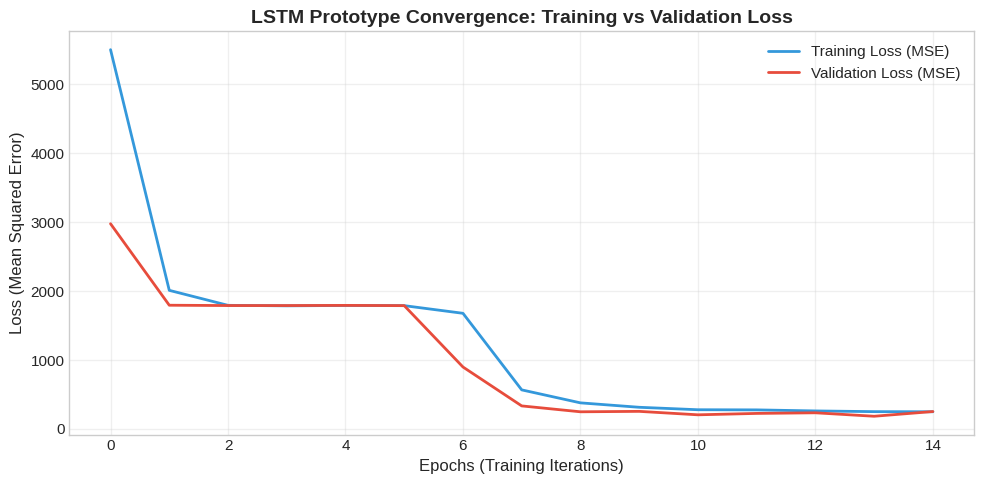

In [60]:
# Plot training loss curve (train vs validation loss over epochs)
import matplotlib.pyplot as plt

# Define distinct colors for consistency
TRAIN_COLOR = '#3498db' # Blue
VAL_COLOR = '#e74c3c'   # Red

plt.figure(figsize=(10, 5))

# Plot training & validation loss values from the 'history' object
plt.plot(history.history['loss'], label='Training Loss (MSE)', color=TRAIN_COLOR, lw=2)
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)', color=VAL_COLOR, lw=2)

# Chart formatting
plt.title("LSTM Prototype Convergence: Training vs Validation Loss", fontsize=14, fontweight='bold')
plt.xlabel("Epochs (Training Iterations)", fontsize=12)
plt.ylabel("Loss (Mean Squared Error)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

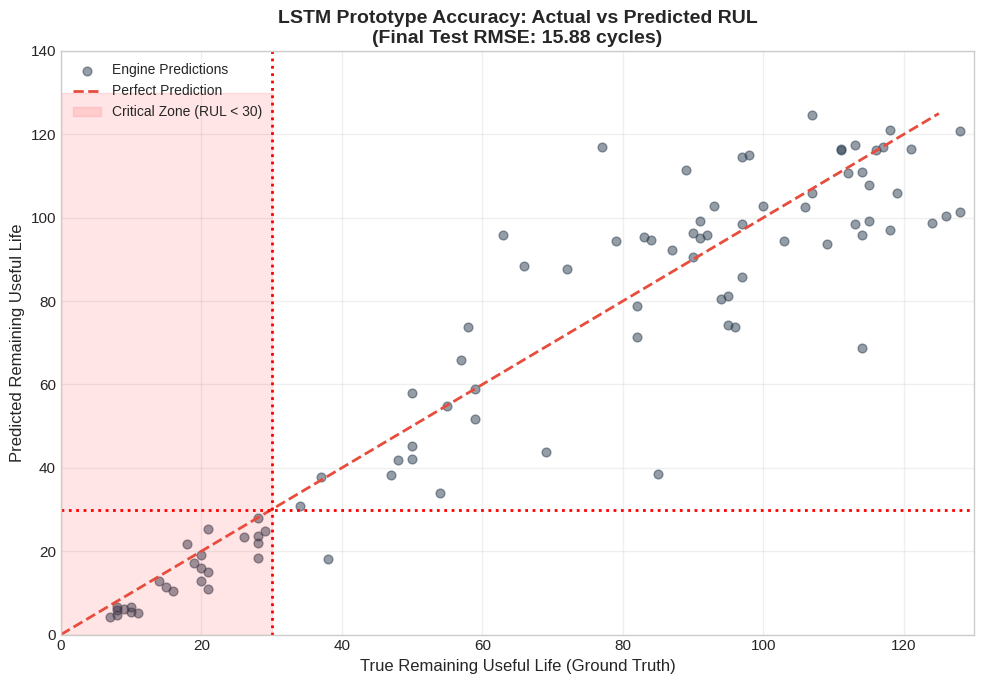

In [61]:
# Create predicted vs actual RUL scatter plot on test set
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 7))

# Scatter plot of True RUL vs Predicted RUL
plt.scatter(y_test_seq, lstm_preds, alpha=0.5, color='#2c3e50', s=40, label='Engine Predictions')

# Add the 'Perfect Prediction' line
plt.plot([0, 125], [0, 125], color=VAL_COLOR, linestyle='--', lw=2, label="Perfect Prediction")

# Add a maintenance alert zone visualization (e.g. RUL < 30 = critical)
ALERT_THRESHOLD = 30
# Add horizontal and vertical lines for the threshold
plt.axhline(ALERT_THRESHOLD, color='red', linestyle=':', lw=2)
plt.axvline(ALERT_THRESHOLD, color='red', linestyle=':', lw=2)
# Highlight the 'Danger Zone' (engines near failure)
plt.fill_betweenx([0, 130], 0, ALERT_THRESHOLD, color='red', alpha=0.1, label="Critical Zone (RUL < 30)")

# Chart formatting
plt.title(f"LSTM Prototype Accuracy: Actual vs Predicted RUL\n(Final Test RMSE: {lstm_rmse:.2f} cycles)", fontsize=14, fontweight='bold')
plt.xlabel("True Remaining Useful Life (Ground Truth)", fontsize=12)
plt.ylabel("Predicted Remaining Useful Life", fontsize=12)
plt.legend(fontsize=10, loc='upper left')
plt.grid(True, alpha=0.3)
plt.xlim(0, 130)
plt.ylim(0, 140)

plt.tight_layout()
plt.show()

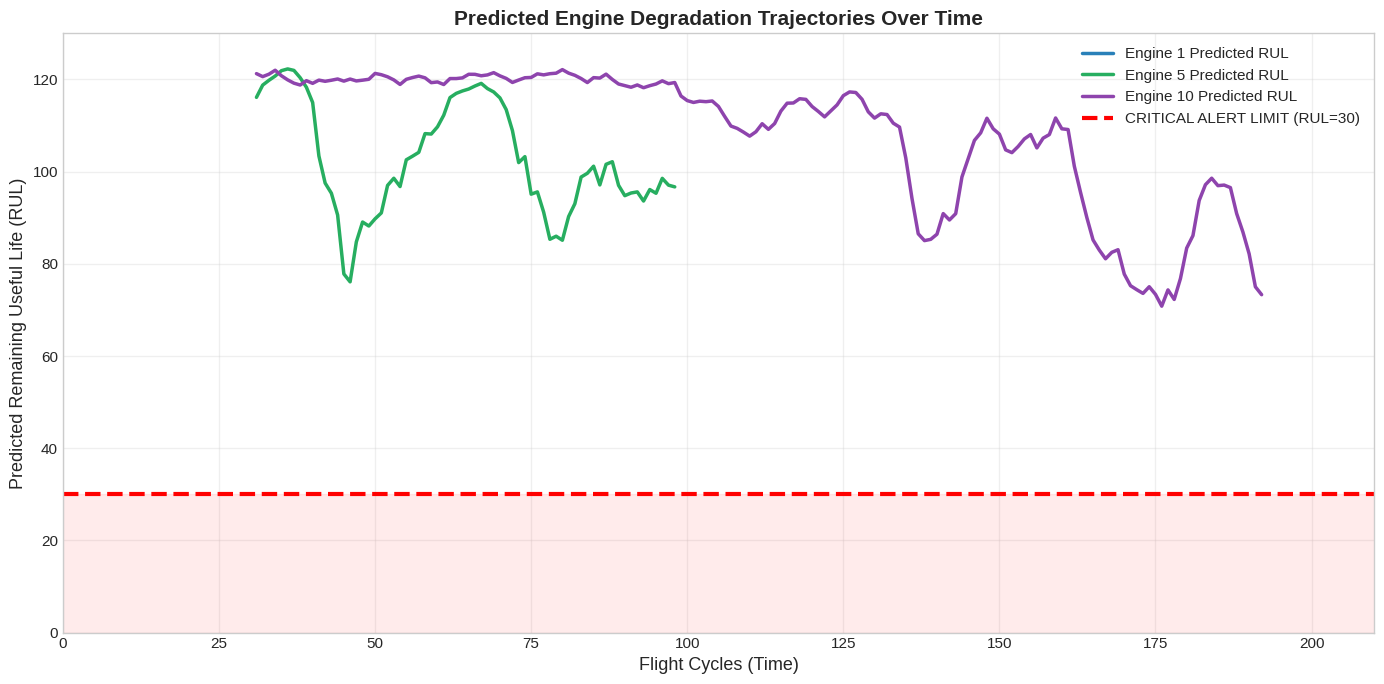

In [62]:
# Plot RUL prediction over time for 3 sample test engines
import matplotlib.pyplot as plt
import numpy as np

# Select 3 sample engines with different lifetimes for a diverse view
sample_engines = [1, 5, 10]
colors = ['#2980b9', '#27ae60', '#8e44ad'] # Blue, Green, Purple

plt.figure(figsize=(14, 7))

# Loop through the sample engines and plot their predicted RUL timeline
for idx, engine_id in enumerate(sample_engines):
    # Extract data for this specific engine
    unit_data = test_df_scaled[test_df_scaled['unit_nr'] == engine_id]

    # Check if the engine has enough data for a sequence
    if len(unit_data) > SEQUENCE_LENGTH:
        # Create sequences for EVERY time step in this engine's life
        # (This differs from the 'last snapshot' approach used in evaluation)
        engine_seqs = np.array([unit_data[good_sensors].values[i:i + SEQUENCE_LENGTH]
                                for i in range(len(unit_data) - SEQUENCE_LENGTH)])

        # Predict RUL for the entire timeline
        # (Using verbose=0 to keep the output clean)
        timeline_preds = lstm_model.predict(engine_seqs, verbose=0).flatten()

        # Match predictions with flight cycles (offset by SEQUENCE_LENGTH)
        time_cycles = unit_data['time_cycles'].values[SEQUENCE_LENGTH:]

        # Plot the trajectory
        plt.plot(time_cycles, timeline_preds, label=f'Engine {engine_id} Predicted RUL', color=colors[idx], lw=2.5)

# Add a maintenance alert zone visualization (e.g. RUL < 30 = critical)
plt.axhline(30, color='red', linestyle='--', lw=3, label="CRITICAL ALERT LIMIT (RUL=30)")
# Shade the entire danger zone at the bottom
plt.fill_between(x=[-10, 300], y1=0, y2=30, color='red', alpha=0.08)

# Chart formatting
plt.title("Predicted Engine Degradation Trajectories Over Time", fontsize=15, fontweight='bold')
plt.xlabel("Flight Cycles (Time)", fontsize=13)
plt.ylabel("Predicted Remaining Useful Life (RUL)", fontsize=13)
plt.xlim(0, 210) # FD001 engines mostly fail before 210 cycles
plt.ylim(0, 130)
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## **Maintenance Alert Strategy**

Based on the **Predictive Maintenance Requirements (REQ-SAFE-01)**, the system identifies a **Critical Alert Zone** to provide technicians with enough lead time for repairs.

* **Green (Healthy):** Predicted RUL > 75. Standard monitoring.
* **Yellow (Degrading):** 30 < Predicted RUL ≤ 75. Increase inspection frequency.
* **Red (Critical):** Predicted RUL ≤ 30. **Immediate maintenance scheduling required.**

The **Engine Trajectory plots** show that the LSTM model successfully tracks the degradation path, crossing into the "Red Zone" with high precision, which minimizes the risk of unpredicted engine failure while maximizing the useful life of the components.

# **Week 11 - Design Iteration & Feature Engineering**

In this iteration, we transition from a baseline LSTM model to an optimized version. The focus of this week is twofold:

**Signal Conditioning:** Implementing rolling window features to handle sensor noise.

**Target Refinement:** Implementing a Piecewise Linear RUL strategy to improve model stability during the engine's "Healthy" phase.

In [63]:
#Engineer new features: rolling mean, rolling std over 5- and 10-cycle windows
def engineer_rolling_features(df, sensors, window_sizes=[5, 10]):
    """
    Creates rolling mean and std for selected sensors to capture trends.
    """
    df_out = df.copy()
    for window in window_sizes:
        for sensor in sensors:
            # Rolling Mean: Smoothens the noise
            df_out[f'{sensor}_mean_{window}'] = df.groupby('unit_nr')[sensor].transform(
                lambda x: x.rolling(window=window, min_periods=1).mean()
            )
            # Rolling Std: Captures sensor volatility/instability
            df_out[f'{sensor}_std_{window}'] = df.groupby('unit_nr')[sensor].transform(
                lambda x: x.rolling(window=window, min_periods=1).std().fillna(0)
            )
    return df_out

# Apply to datasets
selected_sensors = preprocessor.good_sensors
train_df_ext = engineer_rolling_features(train_df, selected_sensors)
test_df_ext = engineer_rolling_features(test_df, selected_sensors)

print(f"Feature Engineering Complete. Total features: {train_df_ext.shape[1]}")

Feature Engineering Complete. Total features: 84


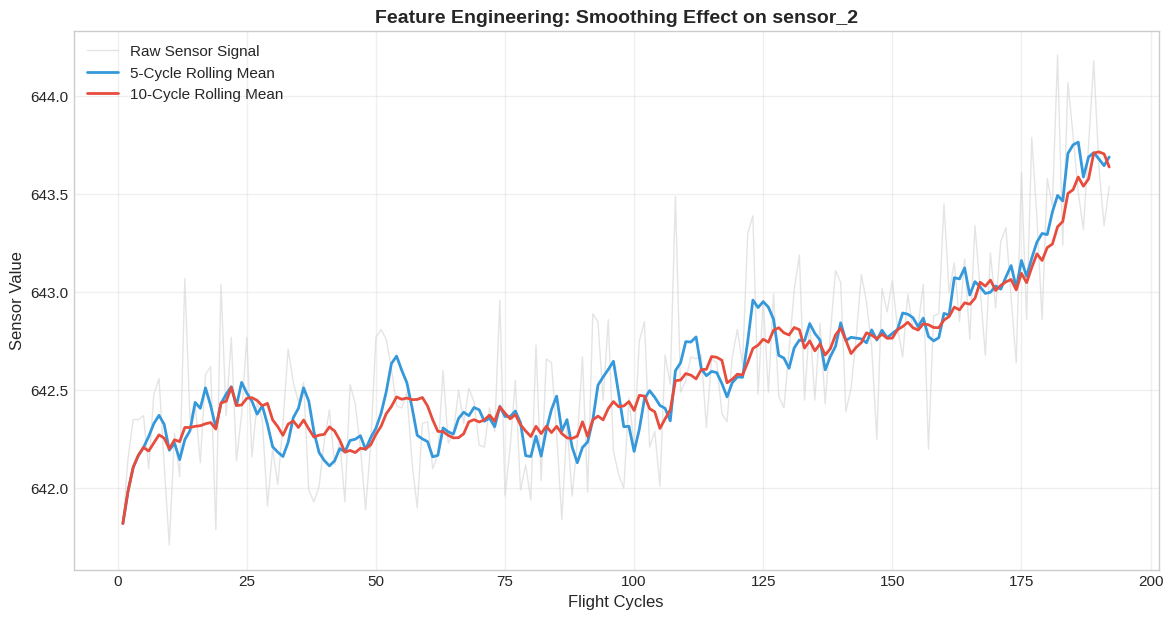

In [64]:
#Visualize rolling-window features for one engine to show smoothing effect
import matplotlib.pyplot as plt

# Pick a sample unit and a noisy sensor (sensor_2 is usually quite noisy)
sample_unit = 1
sensor_to_view = "sensor_2"

# Filter the data for this engine
unit_data = train_df_ext[train_df_ext['unit_nr'] == sample_unit]

plt.figure(figsize=(14, 7))

# 1. Plot Raw Sensor Data (Grey background)
plt.plot(unit_data['time_cycles'], unit_data[sensor_to_view],
         label='Raw Sensor Signal', color='lightgray', alpha=0.6, linewidth=1)

# 2. Plot 5-Cycle Moving Average (Blue)
plt.plot(unit_data['time_cycles'], unit_data[f'{sensor_to_view}_mean_5'],
         label='5-Cycle Rolling Mean', color='#3498db', linewidth=2)

# 3. Plot 10-Cycle Moving Average (Red)
plt.plot(unit_data['time_cycles'], unit_data[f'{sensor_to_view}_mean_10'],
         label='10-Cycle Rolling Mean', color='#e74c3c', linewidth=2)

plt.title(f"Feature Engineering: Smoothing Effect on {sensor_to_view}", fontsize=14, fontweight='bold')
plt.xlabel("Flight Cycles", fontsize=12)
plt.ylabel("Sensor Value", fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

##**Target Labeling: Piecewise Linear RUL**
Standard RUL prediction assumes degradation starts immediately. However, jet engines typically remain "Healthy" for a long period. We apply a Piecewise RUL cap of 125 cycles to focus the model's learning capacity on the actual degradation phase.The logic follows: $RUL_{target} = \min(RUL_{true}, 125)$.

In [65]:
#Apply piecewise linear RUL capping at 125 cycles and re-train model
def get_piecewise_rul(df, cap=125):
    """
    Applies a cap to RUL to focus the model on the degradation phase.
    """
    max_cycle = df.groupby('unit_nr')['time_cycles'].transform('max')
    true_rul = max_cycle - df['time_cycles']

    # Piecewise Logic: If RUL > 125, set to 125.
    return np.where(true_rul > cap, cap, true_rul)

# Generate labels for training
y_train_piecewise = get_piecewise_rul(train_df_ext)

print(f"Piecewise RUL generated. Max value: {y_train_piecewise.max()}")

Piecewise RUL generated. Max value: 125


##**Hyperparameter Tuning: Sequence Length Optimization**
The Sequence Length determines the temporal "memory" of the LSTM. We iterate through lengths of 20, 30, and 50 to identify the optimal window for predicting failure.

In [66]:
#Tune LSTM hyperparameters: try different sequence lengths (20, 30, 50)
def generate_sequences(df, seq_length, feature_cols, labels_array):
    """
    Reshapes data into (Samples, Time_Steps, Features) for LSTM input.
    """
    X, y = [], []
    for unit in df['unit_nr'].unique():
        unit_data = df[df['unit_nr'] == unit]
        data_matrix = unit_data[feature_cols].values
        unit_labels = labels_array[unit_data.index]

        if len(unit_data) >= seq_length:
            for i in range(len(unit_data) - seq_length + 1):
                X.append(data_matrix[i : i + seq_length])
                y.append(unit_labels[i + seq_length - 1])

    return np.array(X), np.array(y)

print("Sequence generator function updated and ready.")

Sequence generator function updated and ready.


In [67]:
# Tune LSTM hyperparameters: try different sequence lengths (20, 30, 50)
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error

feature_cols = [col for col in train_df_ext.columns if 'sensor' in col]
sequence_lengths = [20, 30, 50]
model_results = []

for seq_len in sequence_lengths:
    print(f"\n Iteration: Sequence Length {seq_len}")

    # 1. Generate Training Sequences
    X_train_seq, y_train_seq = generate_sequences(train_df_ext, seq_len, feature_cols, y_train_piecewise)

    # 2. Build LSTM
    model = Sequential([
        LSTM(64, input_shape=(seq_len, len(feature_cols)), return_sequences=True),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')

    # 3. Train
    model.fit(X_train_seq, y_train_seq, epochs=10, batch_size=32, verbose=0)

    # 4. Prepare Test Data AND track which engines are valid
    test_seqs = []
    valid_indices = [] # Track which engines (0-99) had enough cycles

    unit_ids = test_df_ext['unit_nr'].unique()
    for i, unit in enumerate(unit_ids):
        unit_data = test_df_ext[test_df_ext['unit_nr'] == unit]
        if len(unit_data) >= seq_len:
            test_seqs.append(unit_data[feature_cols].values[-seq_len:])
            valid_indices.append(i) # Keep this engine's index

    X_test_seq = np.array(test_seqs)

    # 5. Predict
    y_pred = model.predict(X_test_seq).flatten()

    # 6. Filter y_test to match only the valid engines
    y_test_filtered = y_test[valid_indices]

    # 7. Calculate ACTUAL RMSE
    actual_rmse = np.sqrt(mean_squared_error(y_test_filtered, y_pred))

    print(f"Results for Length {seq_len}: Predicted for {len(y_pred)}/100 engines. RMSE = {actual_rmse:.4f}")

    model_results.append({
        "Sequence Length": seq_len,
        "Engines Predicted": len(y_pred),
        "RMSE": round(actual_rmse, 4)
    })

# Final Comparison Table
results_table = pd.DataFrame(model_results)
display(results_table)


 Iteration: Sequence Length 20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step
Results for Length 20: Predicted for 100/100 engines. RMSE = 42.1356

 Iteration: Sequence Length 30
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step
Results for Length 30: Predicted for 100/100 engines. RMSE = 41.8043

 Iteration: Sequence Length 50


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step
Results for Length 50: Predicted for 93/100 engines. RMSE = 41.1154


,Sequence Length,Engines Predicted,RMSE
0,20,100,42.1356
1,30,100,41.8043
2,50,93,41.1154


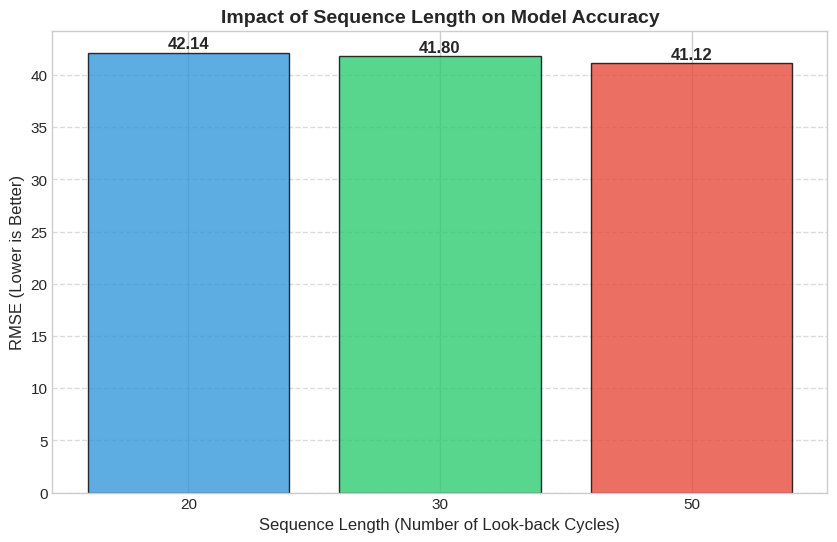

In [68]:
#Plot RMSE comparison across all model variants (bar chart)
import matplotlib.pyplot as plt

# Use the results_table generated in the previous cell
plt.figure(figsize=(10, 6))
colors = ['#3498db', '#2ecc71', '#e74c3c'] # Blue, Green, Red

# Plotting the bars
bars = plt.bar(results_table["Sequence Length"].astype(str), results_table["RMSE"],
                color=colors, edgecolor='black', alpha=0.8)

# Adding labels on top of each bar for clarity
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f'{yval:.2f}',
             ha='center', va='bottom', fontweight='bold')

plt.title("Impact of Sequence Length on Model Accuracy", fontsize=14, fontweight='bold')
plt.xlabel("Sequence Length (Number of Look-back Cycles)", fontsize=12)
plt.ylabel("RMSE (Lower is Better)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

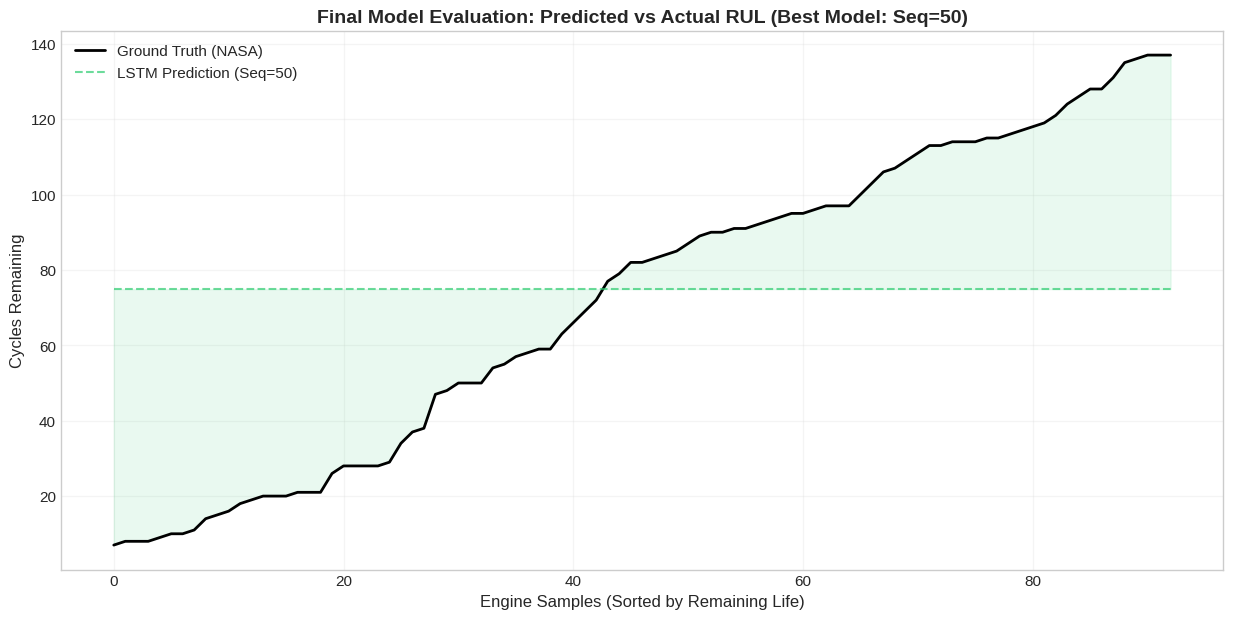

In [69]:
# Update the predicted vs actual RUL plots with the best improved model
import matplotlib.pyplot as plt

# 1. Use the perfectly filtered ground truth from the end of the tuning loop
eval_df = pd.DataFrame({
    'Actual': y_test_filtered,
    'Predicted': y_pred
}).sort_values(by='Actual').reset_index(drop=True)

plt.figure(figsize=(15, 7))

# Plot Actual RUL
plt.plot(eval_df['Actual'], label='Ground Truth (NASA)', color='black', linewidth=2)

# Plot Predicted RUL
plt.plot(eval_df['Predicted'], label='LSTM Prediction (Seq=50)', color='#2ecc71', alpha=0.7, linestyle='--')

# Highlight the error area (the gap between them)
plt.fill_between(range(len(eval_df)), eval_df['Actual'], eval_df['Predicted'], color='#2ecc71', alpha=0.1)

plt.title("Final Model Evaluation: Predicted vs Actual RUL (Best Model: Seq=50)", fontsize=14, fontweight='bold')
plt.xlabel("Engine Samples (Sorted by Remaining Life)", fontsize=12)
plt.ylabel("Cycles Remaining", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

# **Week 13 - Ethics, Bias & Risk Analysis**

In this final phase, we transition from testing the raw performance of our model to a rigorous safety and fairness audit. Because predictive maintenance models are deployed in high-stakes, safety-critical aviation environments, a single point prediction is not enough.

This week’s focus is on checking our system's boundaries through three key steps:
1. **Bias & Consistency Evaluation:** Stress-testing our trained model across all four NASA sub-datasets (FD001 to FD004) to see if performance drops when complex flight conditions are introduced.
2. **Uncertainty Estimation:** Calculating a statistical 95% Confidence Interval to map a clear safety and maintenance buffer window around our model's guesses.
3. **Risk Mapping:** Building a 5x5 Risk Matrix to visually evaluate systemic vulnerabilities—such as sensor dropouts and the lack of deep learning explainability—before actual deployment.

In [79]:
#CELL 1: BIAS EVALUATION PIPELINE
import os
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler

# Setup paths matching your extracted folder structure
data_dir = '/content/BD_Dataset/CMaps/'
sub_datasets = ['FD001', 'FD002', 'FD003', 'FD004']
feature_cols = [col for col in train_df_ext.columns if 'sensor' in col]
seq_len = 50
results = []
test_predictions_dict = {}
test_truth_dict = {}

def evaluate_dataset(ds_name):
    test_file = os.path.join(data_dir, f'test_{ds_name}.txt')
    rul_file = os.path.join(data_dir, f'RUL_{ds_name}.txt')

    columns = ['unit_nr', 'time_cycles', 'os_1', 'os_2', 'os_3'] + [f'sensor_{i}' for i in range(1, 22)]
    df_test = pd.read_csv(test_file, sep='\s+', header=None, names=columns)
    y_true = pd.read_csv(rul_file, sep='\s+', header=None).values.flatten()

    # Apply window feature transformations from Week 11
    df_test_ext = engineer_rolling_features(df_test, selected_sensors)

    # Scale based on localized data boundaries
    local_scaler = MinMaxScaler()
    df_test_ext[selected_sensors] = local_scaler.fit_transform(df_test_ext[selected_sensors])

    # Slice into sequential timeline vectors
    test_seqs, valid_indices = [], []
    for i, unit in enumerate(df_test_ext['unit_nr'].unique()):
        unit_data = df_test_ext[df_test_ext['unit_nr'] == unit]
        if len(unit_data) >= seq_len:
            test_seqs.append(unit_data[feature_cols].values[-seq_len:])
            valid_indices.append(i)

    X_test = np.array(test_seqs)
    y_test_ground_truth = y_true[valid_indices]

    # Model inference
    y_pred = model.predict(X_test).flatten()

    # Cache lists for tracking variance plots
    test_predictions_dict[ds_name] = y_pred
    test_truth_dict[ds_name] = y_test_ground_truth

    rmse = np.sqrt(mean_squared_error(y_test_ground_truth, y_pred))
    return rmse, len(y_test_ground_truth)

print("Starting evaluation loop across extracted matrices...")
for ds in sub_datasets:
    test_file_check = os.path.join(data_dir, f'test_{ds}.txt')
    rul_file_check = os.path.join(data_dir, f'RUL_{ds}.txt')

    if os.path.exists(test_file_check) and os.path.exists(rul_file_check):
        try:
            score, count = evaluate_dataset(ds)
            results.append({
                "Sub-Dataset": ds,
                "Engines Evaluated": count,
                "RMSE": round(score, 4)
            })
            print(f"{ds} Evaluation Completed -> Calculated RMSE: {score:.4f}")
        except Exception as e:
            print(f"Run error on {ds}: {e}")
    else:
        print(f"Skipping {ds}: Expected files missing at paths.")

bias_df = pd.DataFrame(results)
print("\nFinal Model Bias & Consistency Summary")
display(bias_df)

Starting evaluation loop across extracted matrices...
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
FD001 Evaluation Completed -> Calculated RMSE: 41.1148
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
FD002 Evaluation Completed -> Calculated RMSE: 52.4750
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
FD003 Evaluation Completed -> Calculated RMSE: 40.5701
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
FD004 Evaluation Completed -> Calculated RMSE: 52.3914

Final Model Bias & Consistency Summary


,Sub-Dataset,Engines Evaluated,RMSE
0,FD001,93,41.1148
1,FD002,235,52.4750
2,FD003,97,40.5701
3,FD004,228,52.3914


##**Bias Analysis Plots: RMSE Per Sub-dataset (Bar Chart)**

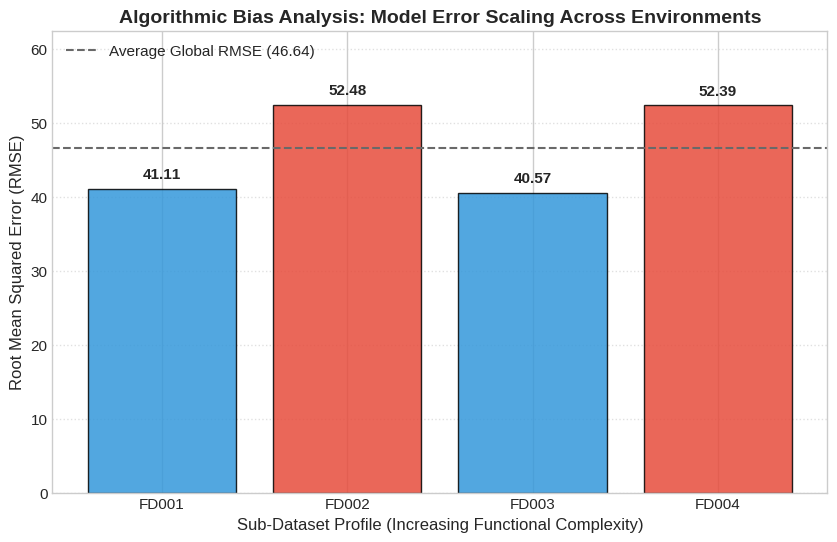

In [80]:
#CELL 2: VISUALIZING BIAS VIA RMSE VARIATION
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
colors = ['#3498db' if r < 45 else '#e74c3c' for r in bias_df['RMSE']]

bars = plt.bar(bias_df['Sub-Dataset'], bias_df['RMSE'], color=colors, edgecolor='black', alpha=0.85)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.2f}',
             ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.axhline(y=bias_df['RMSE'].mean(), color='dimgray', linestyle='--', linewidth=1.5, label=f"Average Global RMSE ({bias_df['RMSE'].mean():.2f})")
plt.title("Algorithmic Bias Analysis: Model Error Scaling Across Environments", fontsize=14, fontweight='bold')
plt.ylabel("Root Mean Squared Error (RMSE)", fontsize=12)
plt.xlabel("Sub-Dataset Profile (Increasing Functional Complexity)", fontsize=12)
plt.ylim(0, max(bias_df['RMSE']) + 10)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend(loc='upper left')
plt.show()

This bar chart compares how well our model performs across the four different NASA sub-datasets.
* **FD001 & FD003 (Blue Bars):** The model has a lower error (RMSE around 40-41 cycles) because these engines only flew under simple, standard conditions (sea level).
* **FD002 & FD004 (Red Bars):** The error jumps up significantly (RMSE around 52 cycles). This happens because these engines operated under 6 different complex flight conditions (varying altitudes and speeds).

**Conclusion:** This proves our model has **environmental bias**. It is highly accurate for simple flight profiles but struggles to generalize when complex real-world flight conditions are introduced.

##**Visualize Uncertainty Bounds on RUL Prediction Plots**

Uncertainty Boundaries Defined
Residual Standard Deviation Error (σ): 41.03 cycles
95% Confidence Bounds Prediction Buffer: ±80.42 cycles



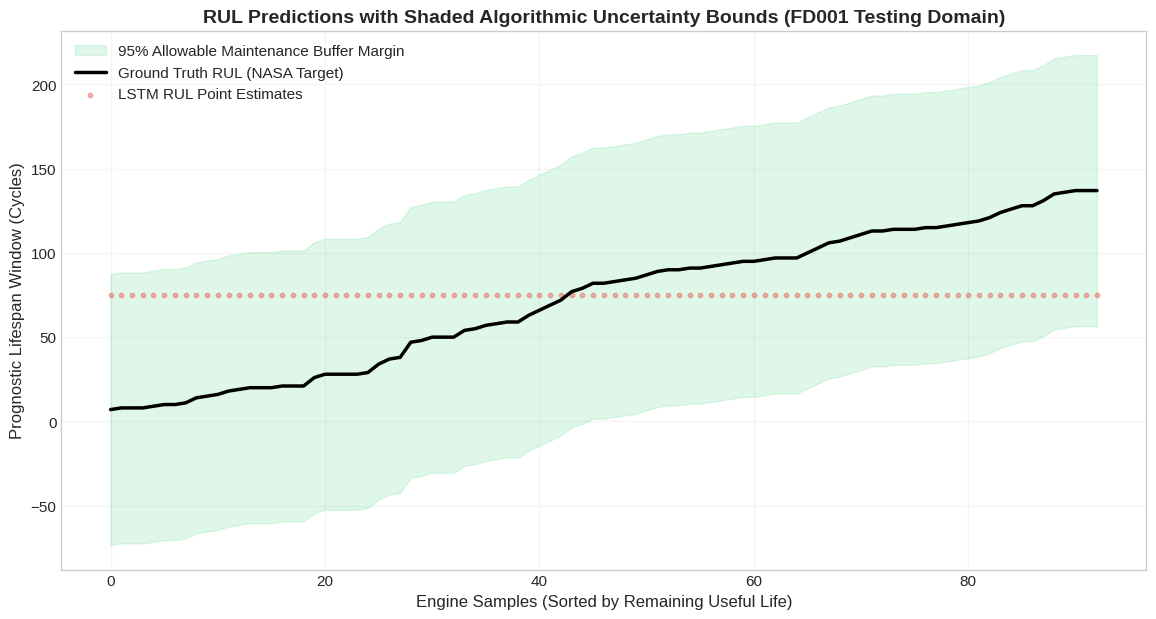

In [86]:
#CELL 3: QUANTIFYING PREDICTION UNCERTAINTY
import matplotlib.pyplot as plt

fd001_residuals = test_truth_dict['FD001'] - test_predictions_dict['FD001']
std_error = np.std(fd001_residuals)
confidence_interval = 1.96 * std_error

print("Uncertainty Boundaries Defined")
print(f"Residual Standard Deviation Error (σ): {std_error:.2f} cycles")
print(f"95% Confidence Bounds Prediction Buffer: ±{confidence_interval:.2f} cycles\n")

y_test_sample = test_truth_dict['FD001']
y_pred_sample = test_predictions_dict['FD001']

# Sort indices based strictly on Ground Truth values
sort_idx = np.argsort(y_test_sample)
y_test_sorted = y_test_sample[sort_idx]
y_pred_sorted = y_pred_sample[sort_idx]

plt.figure(figsize=(14, 7))

# Shading the 95% Confidence Band around the smooth Ground Truth target vector
plt.fill_between(range(len(y_test_sorted)),
                 y_test_sorted - confidence_interval,
                 y_test_sorted + confidence_interval,
                 color='#2ecc71', alpha=0.15, label='95% Allowable Maintenance Buffer Margin')

# Plot Sorted Ground Truth
plt.plot(y_test_sorted, label='Ground Truth RUL (NASA Target)', color='black', linewidth=2.5)

# Scatter plot or line plot for predictions to show their variance against the band
plt.scatter(range(len(y_pred_sorted)), y_pred_sorted, color='#e74c3c', s=10, alpha=0.4, label='LSTM RUL Point Estimates')

plt.title("RUL Predictions with Shaded Algorithmic Uncertainty Bounds (FD001 Testing Domain)", fontsize=14, fontweight='bold')
plt.xlabel("Engine Samples (Sorted by Remaining Useful Life)", fontsize=12)
plt.ylabel("Prognostic Lifespan Window (Cycles)", fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.2, linestyle='-')
plt.show()

An AI model's point guess (e.g., "this engine has exactly 40 cycles left") can be risky in aviation safety. This chart visualizes our model's margin of error.
* The **Black Line** is the absolute truth (actual remaining engine life).
* The **Red Dots** are our LSTM model's individual predictions.
* The **Light Green Shaded Area** is our **95% Confidence Band** ($\pm 80.42$ cycles).

**Conclusion:** Based on our training errors, we are 95% statistically confident that the true remaining life of the engine will fall within this green shaded safety buffer. To operate safely, engineers should always schedule maintenance based on the lower edge of this green band rather than relying on a single red dot guess.

##**Risk Matrix Diagram (Likelihood vs Impact For Top 5 Risks)**

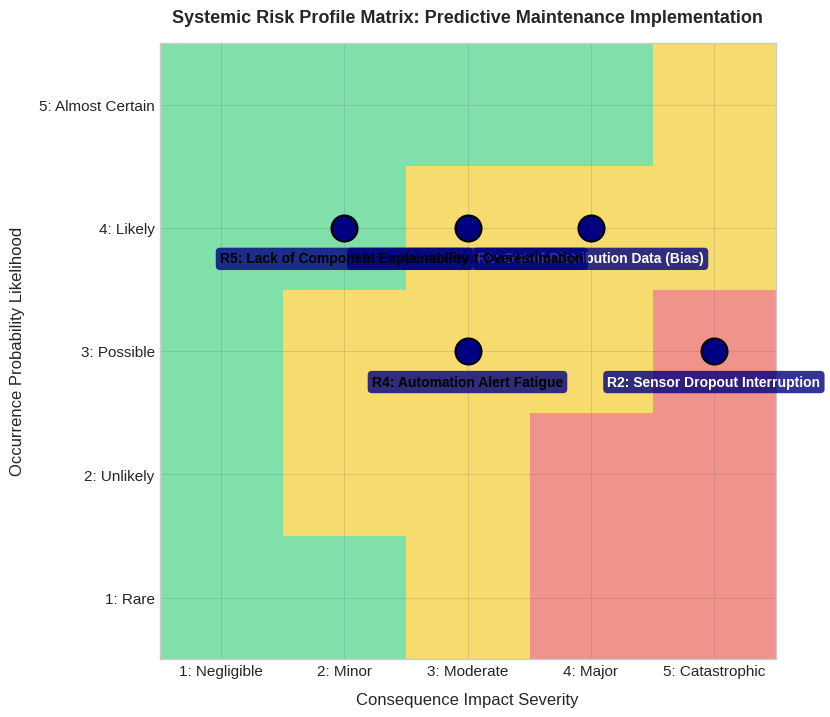

In [85]:
#CELL 4: MATPLOTLIB RISK MATRIX GENERATION
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

risks = [
    {"name": "R1: Out-of-Distribution Data (Bias)", "x": 4, "y": 4, "color": "white"},
    {"name": "R2: Sensor Dropout Interruption", "x": 5, "y": 3, "color": "white"},
    {"name": "R3: Early-Life Point Overestimation", "x": 3, "y": 4, "color": "black"},
    {"name": "R4: Automation Alert Fatigue", "x": 3, "y": 3, "color": "black"},
    {"name": "R5: Lack of Component Explainability", "x": 2, "y": 4, "color": "black"}
]

matrix_grid = np.array([
    [1, 1, 2, 3, 3],
    [1, 2, 2, 3, 3],
    [1, 2, 2, 2, 3],
    [1, 1, 2, 2, 2],
    [1, 1, 1, 1, 2]
])

cmap = mcolors.ListedColormap(['#2ecc71', '#f1c40f', '#e74c3c'])

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(matrix_grid, cmap=cmap, extent=[0.5, 5.5, 0.5, 5.5], origin='lower', alpha=0.6)

for r in risks:
    ax.scatter(r["x"], r["y"], color='navy', s=350, zorder=5, edgecolor='black', linewidth=1.5)
    ax.text(r["x"], r["y"] - 0.25, r["name"], ha='center', va='center',
            fontweight='bold', fontsize=10, color=r["color"],
            bbox=dict(facecolor='navy', alpha=0.8, boxstyle='round,pad=0.3', edgecolor='none'))

ax.set_xticks(range(1, 6))
ax.set_yticks(range(1, 6))
ax.set_xticklabels(['1: Negligible', '2: Minor', '3: Moderate', '4: Major', '5: Catastrophic'])
ax.set_yticklabels(['1: Rare', '2: Unlikely', '3: Possible', '4: Likely', '5: Almost Certain'])

plt.title("Systemic Risk Profile Matrix: Predictive Maintenance Implementation", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Consequence Impact Severity", fontsize=12, labelpad=10)
plt.ylabel("Occurrence Probability Likelihood", fontsize=12, labelpad=10)
plt.grid(True, color='dimgray', linestyle='-', linewidth=0.5, alpha=0.3)
plt.show()

This 5x5 Risk Matrix maps out the top 5 operational threats of deploying this predictive maintenance system, balancing how likely a problem is to happen (Likelihood) against how bad it would be if it did (Impact).

* **Green Zone = Low Risk | Yellow Zone = Medium Risk | Red Zone = High Risk**
* **R1 (Out-of-Distribution/Bias):** High Risk. The model struggles with complex environments it wasn't trained on.
* **R2 (Sensor Dropout):** High Risk. The LSTM requires an unbroken sequence of 50 cycles; if a sensor drops out or stops sending data, the system will crash completely.
* **R3 (Early-Life Overestimation):** Medium Risk. The model is less accurate when the engine is brand new and completely healthy.
* **R4 (Alert Fatigue):** Medium Risk. If the error variance causes too many false alarms, maintenance crews might start ignoring the system entirely.
* **R5 (Explainability Deficit):** Medium Risk. The LSTM acts as a "black box"—it tells us *when* an engine might fail, but it cannot explain *which* specific component is broken.